# 02 - Exploratory Data Analysis (EDA)

## Dataset Description

This exploratory analysis is based on genomic evaluations provided by Semex for 668 animals from a commercial Holstein herd.

The analyses describe the characteristics of the **genotyped population included in the genomic database** and should not be interpreted as representing the complete herd or actual production performance.
## Objective

Describe the genomic and demographic characteristics of the Holstein herd before performing statistical analyses.

---

## Research Question

What are the main characteristics of the population under study?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")

print(f"Dataset loaded successfully.")
print(f"Number of cows: {len(df)}")

Dataset loaded successfully.
Number of cows: 668


In [3]:
# ============================================================
# DISTRIBUTION OF PROOF SOURCES
# ============================================================

proof = (
    df["Proof Source"]
    .value_counts()
    .rename_axis("Proof Source")
    .reset_index(name="Count")
)

proof

,Proof Source,Count
0,GPA,326
1,GEBV,277
2,SMX PA,36
3,EBV,16
4,PA,13


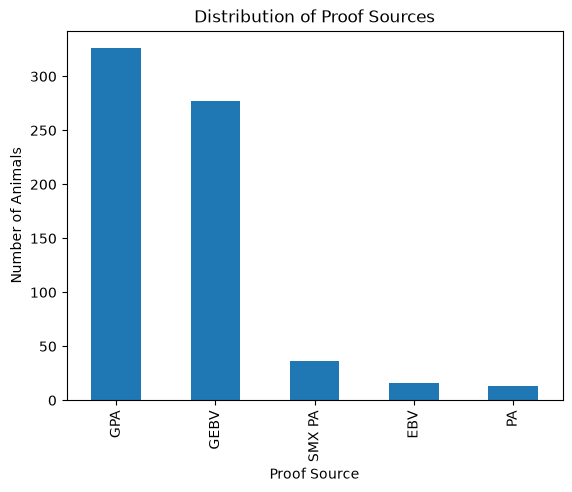

In [4]:
# ============================================================
# BAR CHART OF PROOF SOURCES
# ============================================================

proof.plot.bar(
    x="Proof Source",
    y="Count",
    legend=False
)

plt.title("Distribution of Proof Sources")
plt.xlabel("Proof Source")
plt.ylabel("Number of Animals")

plt.show()

Finding 1: The herd is composed primarily of animals with genomic evaluations (GPA and GEBV), while only a small proportion of animals rely on pedigree-based or traditional evaluations (PA, SMX PA, and EBV).

In [5]:
# ============================================================
# BIRTH YEAR DISTRIBUTION
# ============================================================

birth_year = (
    df["year"]
    .value_counts()
    .sort_index()
)

display(birth_year)

year
2013      1
2015      1
2016      3
2017      6
2018     13
2019     20
2020     30
2021     48
2022     71
2023     83
2024    138
2025    164
2026     90
Name: count, dtype: int64

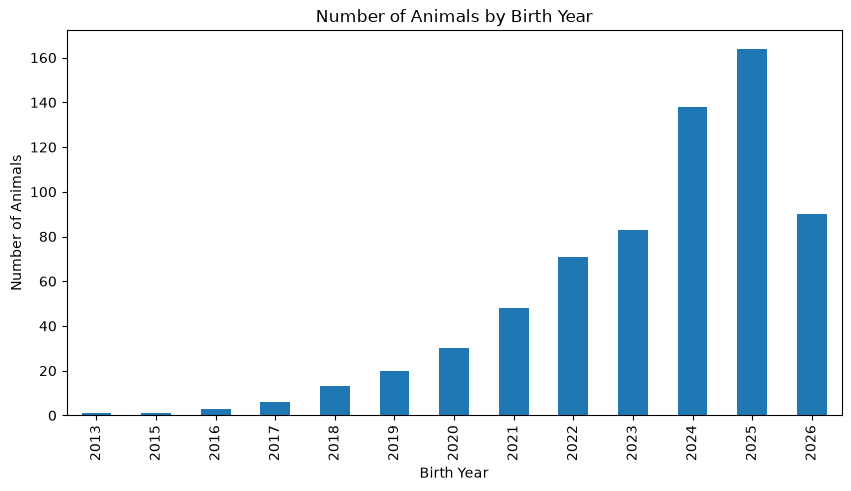

In [7]:
# ============================================================
# NUMBER OF ANIMALS BY BIRTH YEAR
# ============================================================

birth_year.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Animals by Birth Year")
plt.xlabel("Birth Year")
plt.ylabel("Number of Animals")

plt.show()

In [8]:
# ============================================================
# AGE OF ANIMALS
# ============================================================

today = pd.Timestamp.today()

df["Age_Years"] = (
    (today - df["Birth Date"]).dt.days / 365.25
)

C:\Users\arincon\AppData\Local\Temp\ipykernel_38696\3732815407.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Age_Years"] = (


In [9]:
df["Age_Years"].describe()

count    668.000000
mean       2.638432
std        2.156625
min        0.024641
25%        0.960301
50%        2.067077
75%        3.834360
max       12.547570
Name: Age_Years, dtype: float64

In [10]:
# ============================================================
# CALCULATE AGE OF EACH ANIMAL
# ============================================================

today = pd.Timestamp.today()

df["Age_Years"] = (
    (today - df["Birth Date"]).dt.days / 365.25
)

df["Age_Years"] = df["Age_Years"].round(1)

In [11]:
# ============================================================
# SUMMARY OF AGE
# ============================================================

df["Age_Years"].describe()

count    668.000000
mean       2.638772
std        2.156864
min        0.000000
25%        1.000000
50%        2.100000
75%        3.800000
max       12.500000
Name: Age_Years, dtype: float64

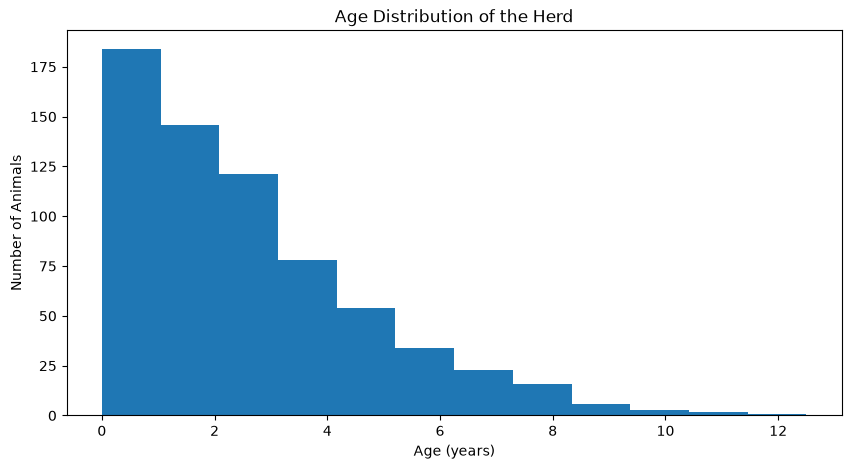

In [12]:
# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(df["Age_Years"], bins=12)

plt.title("Age Distribution of the Herd")
plt.xlabel("Age (years)")
plt.ylabel("Number of Animals")

plt.show()

The genomic dataset includes animals ranging from calves to mature cows, although most genotyped animals are relatively young. The frequency of animals decreases progressively with age, while only a small proportion of genotyped animals are older than eight years. This figure describes the age distribution of the genotyped population included in the genomic database, not necessarily the age structure of the entire herd.

In [13]:
# ============================================================
# LACTATION NUMBER DISTRIBUTION
# ============================================================

lact = (
    df["Lact. Number"]
    .value_counts()
    .sort_index()
)

display(lact)

Lact. Number
0    325
1    121
2     84
3     49
4     48
5     19
6     15
7      4
8      2
9      1
Name: count, dtype: int64

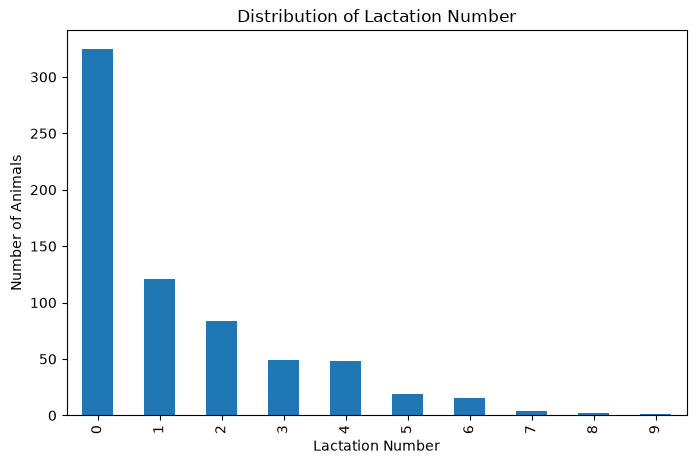

In [14]:
plt.figure(figsize=(8,5))

lact.plot(kind="bar")

plt.title("Distribution of Lactation Number")
plt.xlabel("Lactation Number")
plt.ylabel("Number of Animals")

plt.show()

In [15]:
birth = (
    df["year"]
    .value_counts()
    .sort_index()
)

display(birth)

year
2013      1
2015      1
2016      3
2017      6
2018     13
2019     20
2020     30
2021     48
2022     71
2023     83
2024    138
2025    164
2026     90
Name: count, dtype: int64

In [16]:
df["Genomic Inb. %"].describe()

count    489.000000
mean      12.343354
std        3.478040
min        2.600000
25%       10.200000
50%       12.200000
75%       14.300000
max       25.000000
Name: Genomic Inb. %, dtype: float64

In [17]:
traits = [
    "LPI",
    "Pro$",
    "Milk (kg)",
    "Fat (kg)",
    "Prot (kg)",
    "Conf",
    "MS",
    "FL",
    "DS",
    "RU",
    "HL"
]

df[traits].describe().T

,count,mean,std,min,25%,50%,75%,max
LPI,668.0,3243.244012,285.197607,2300.0,3054.75,3260.5,3453.00,3902.0
Pro$,668.0,1145.092814,733.438846,-1528.0,639.75,1215.0,1665.00,3027.0
Milk (kg),668.0,412.369760,536.767190,-1742.0,50.00,416.0,795.25,1921.0
Fat (kg),668.0,42.544910,33.035614,-62.0,21.00,47.0,66.00,160.0
Prot (kg),668.0,26.049401,20.242287,-38.0,13.00,28.0,40.00,88.0
Conf,668.0,6.172156,4.152491,-8.0,3.00,7.0,9.00,16.0
MS,668.0,4.377246,3.654685,-9.0,2.00,5.0,7.00,13.0
FL,668.0,4.558383,3.885298,-9.0,2.00,5.0,7.00,14.0
DS,668.0,4.079341,3.706390,-8.0,2.00,4.0,7.00,14.0
RU,668.0,3.944611,3.527351,-7.0,1.00,4.0,6.00,14.0


In [18]:
pd.crosstab(df["Proof Source"], df["Lact. Number"])

Lact. Number,0,1,2,3,4,5,6,7,8,9
Proof Source,,,,,,,,,,
EBV,0,1,2,3,3,4,2,1,0,0
GEBV,0,79,80,44,43,13,12,3,2,1
GPA,281,38,2,2,2,1,0,0,0,0
PA,9,2,0,0,0,1,1,0,0,0
SMX PA,35,1,0,0,0,0,0,0,0,0


In [19]:
pd.crosstab(df["Proof Source"], df["year"])

year,2013,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Proof Source,,,,,,,,,,,,,
EBV,0,0,0,1,0,7,1,5,1,1,0,0,0
GEBV,1,1,3,4,13,11,28,41,68,77,30,0,0
GPA,0,0,0,0,0,1,1,2,2,4,101,159,56
PA,0,0,0,1,0,1,0,0,0,1,6,4,0
SMX PA,0,0,0,0,0,0,0,0,0,0,1,1,34


## Distribution of Selection Indexes

The following figure describes the distributions of LPI and Pro$ among animals included in the genomic database.

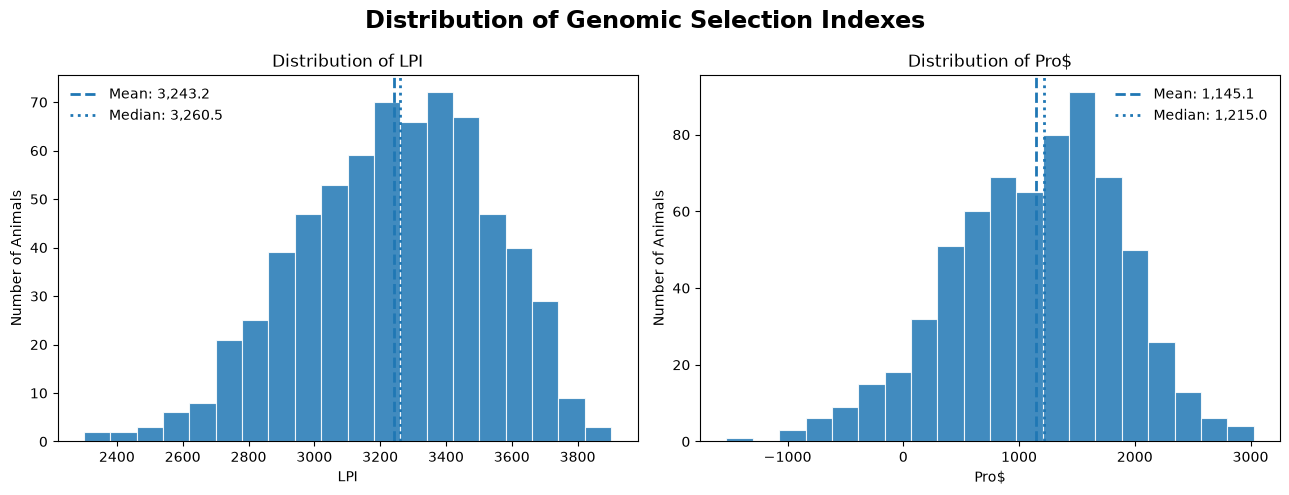

In [20]:
# ============================================================
# LPI AND PRO$ DISTRIBUTIONS
# ============================================================

index_traits = {
    "LPI": "LPI",
    "Pro$": "Pro$"
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5)
)

for ax, (title, column) in zip(axes, index_traits.items()):

    values = df[column].dropna()

    ax.hist(
        values,
        bins=20,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85
    )

    mean_value = values.mean()
    median_value = values.median()

    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:,.1f}"
    )

    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=2,
        label=f"Median: {median_value:,.1f}"
    )

    ax.set_title(f"Distribution of {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Number of Animals")
    ax.legend(frameon=False)

fig.suptitle(
    "Distribution of Genomic Selection Indexes",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Distribution of Genomic Production Evaluations

Milk, Fat, and Protein represent genetic evaluations expressed in kilograms. They do not represent the animals' actual observed production.

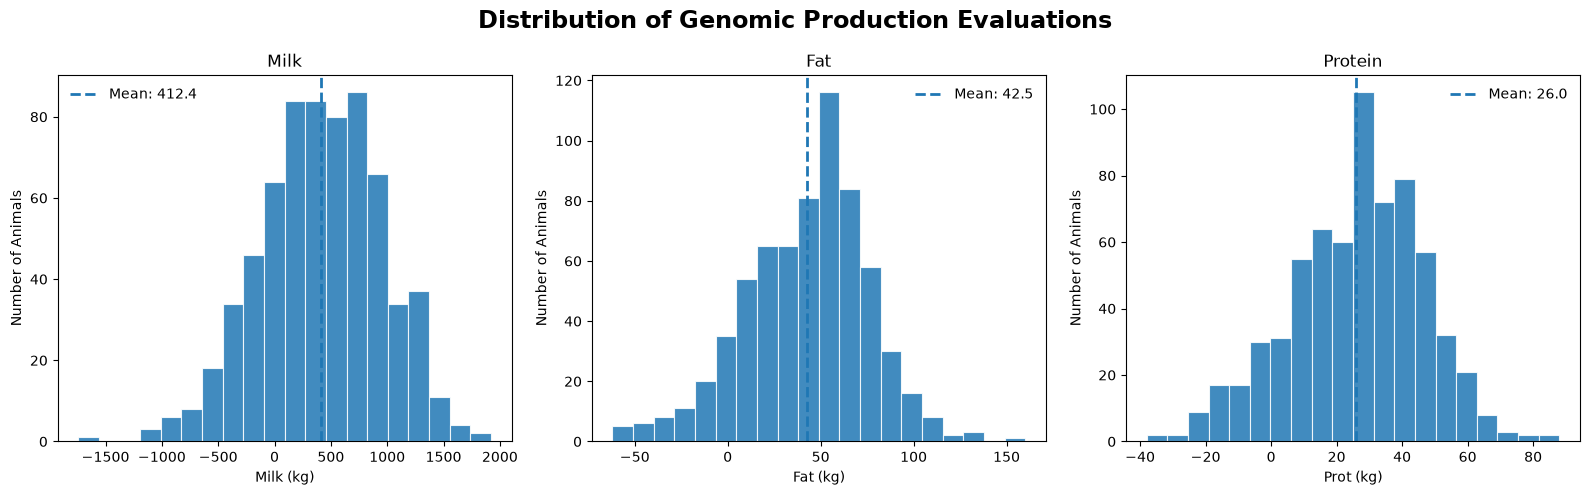

In [21]:
# ============================================================
# PRODUCTION TRAIT DISTRIBUTIONS
# ============================================================

production_traits = {
    "Milk": "Milk (kg)",
    "Fat": "Fat (kg)",
    "Protein": "Prot (kg)"
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

for ax, (trait_name, column) in zip(
    axes,
    production_traits.items()
):

    values = df[column].dropna()

    ax.hist(
        values,
        bins=20,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85
    )

    mean_value = values.mean()

    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:,.1f}"
    )

    ax.set_title(trait_name)
    ax.set_xlabel(f"{column}")
    ax.set_ylabel("Number of Animals")
    ax.legend(frameon=False)

fig.suptitle(
    "Distribution of Genomic Production Evaluations",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Distribution of Genomic Inbreeding

This section describes the distribution of genomic inbreeding coefficients among animals included in the database.

C:\Users\arincon\AppData\Local\Temp\ipykernel_38696\153684523.py:48: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


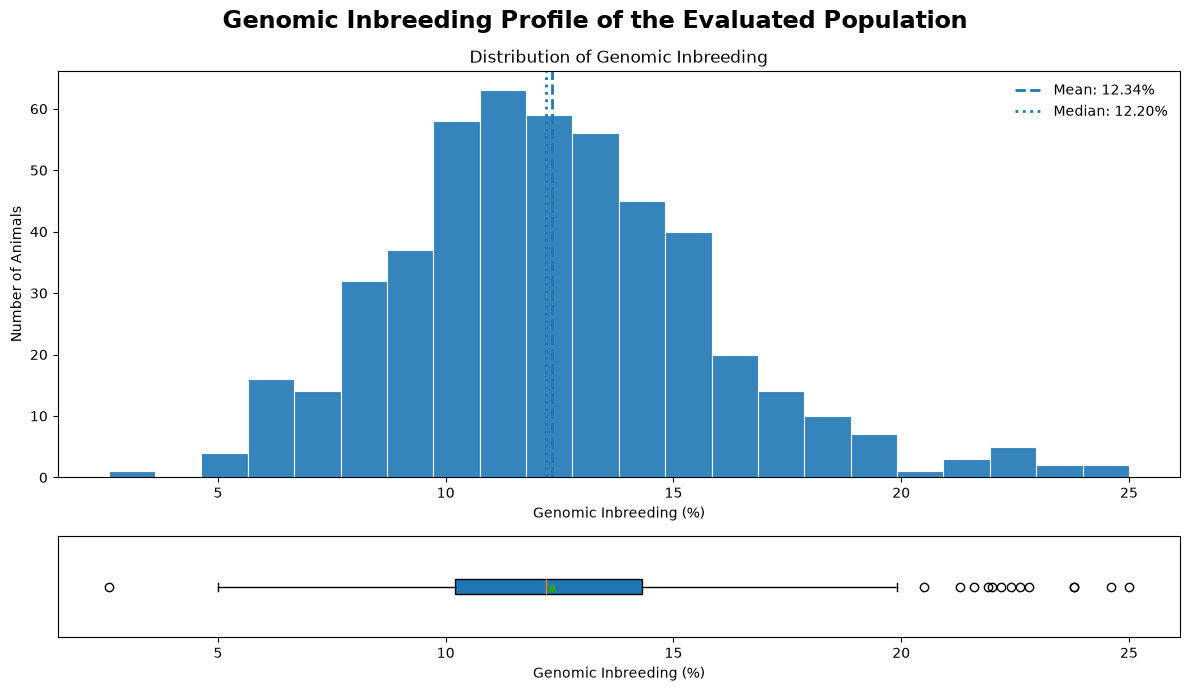

In [22]:
# ============================================================
# GENOMIC INBREEDING DISTRIBUTION
# ============================================================

inbreeding = df["Genomic Inb. %"].dropna()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [4, 1]}
)

# Histogram
axes[0].hist(
    inbreeding,
    bins=22,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.90
)

mean_inbreeding = inbreeding.mean()
median_inbreeding = inbreeding.median()

axes[0].axvline(
    mean_inbreeding,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_inbreeding:.2f}%"
)

axes[0].axvline(
    median_inbreeding,
    linestyle=":",
    linewidth=2,
    label=f"Median: {median_inbreeding:.2f}%"
)

axes[0].set_title(
    "Distribution of Genomic Inbreeding"
)
axes[0].set_xlabel("Genomic Inbreeding (%)")
axes[0].set_ylabel("Number of Animals")
axes[0].legend(frameon=False)

# Horizontal boxplot
axes[1].boxplot(
    inbreeding,
    vert=False,
    patch_artist=True,
    showmeans=True
)

axes[1].set_xlabel("Genomic Inbreeding (%)")
axes[1].set_yticks([])

fig.suptitle(
    "Genomic Inbreeding Profile of the Evaluated Population",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [23]:
# Numerical summary used to interpret the figure

print(f"Animals with genomic inbreeding data: {inbreeding.count()}")
print(f"Mean: {inbreeding.mean():.2f}%")
print(f"Median: {inbreeding.median():.2f}%")
print(f"Minimum: {inbreeding.min():.2f}%")
print(f"Maximum: {inbreeding.max():.2f}%")

Animals with genomic inbreeding data: 489
Mean: 12.34%
Median: 12.20%
Minimum: 2.60%
Maximum: 25.00%


## Distribution of Genomic Conformation Evaluations

The following figure describes the distributions of overall Conformation, Mammary System, Feet and Legs, Dairy Strength, and Rump genomic evaluations.

## Distribution of Genomic Conformation Evaluations

The following figure describes the distributions of overall Conformation, Mammary System, Feet and Legs, Dairy Strength, and Rump genomic evaluations.


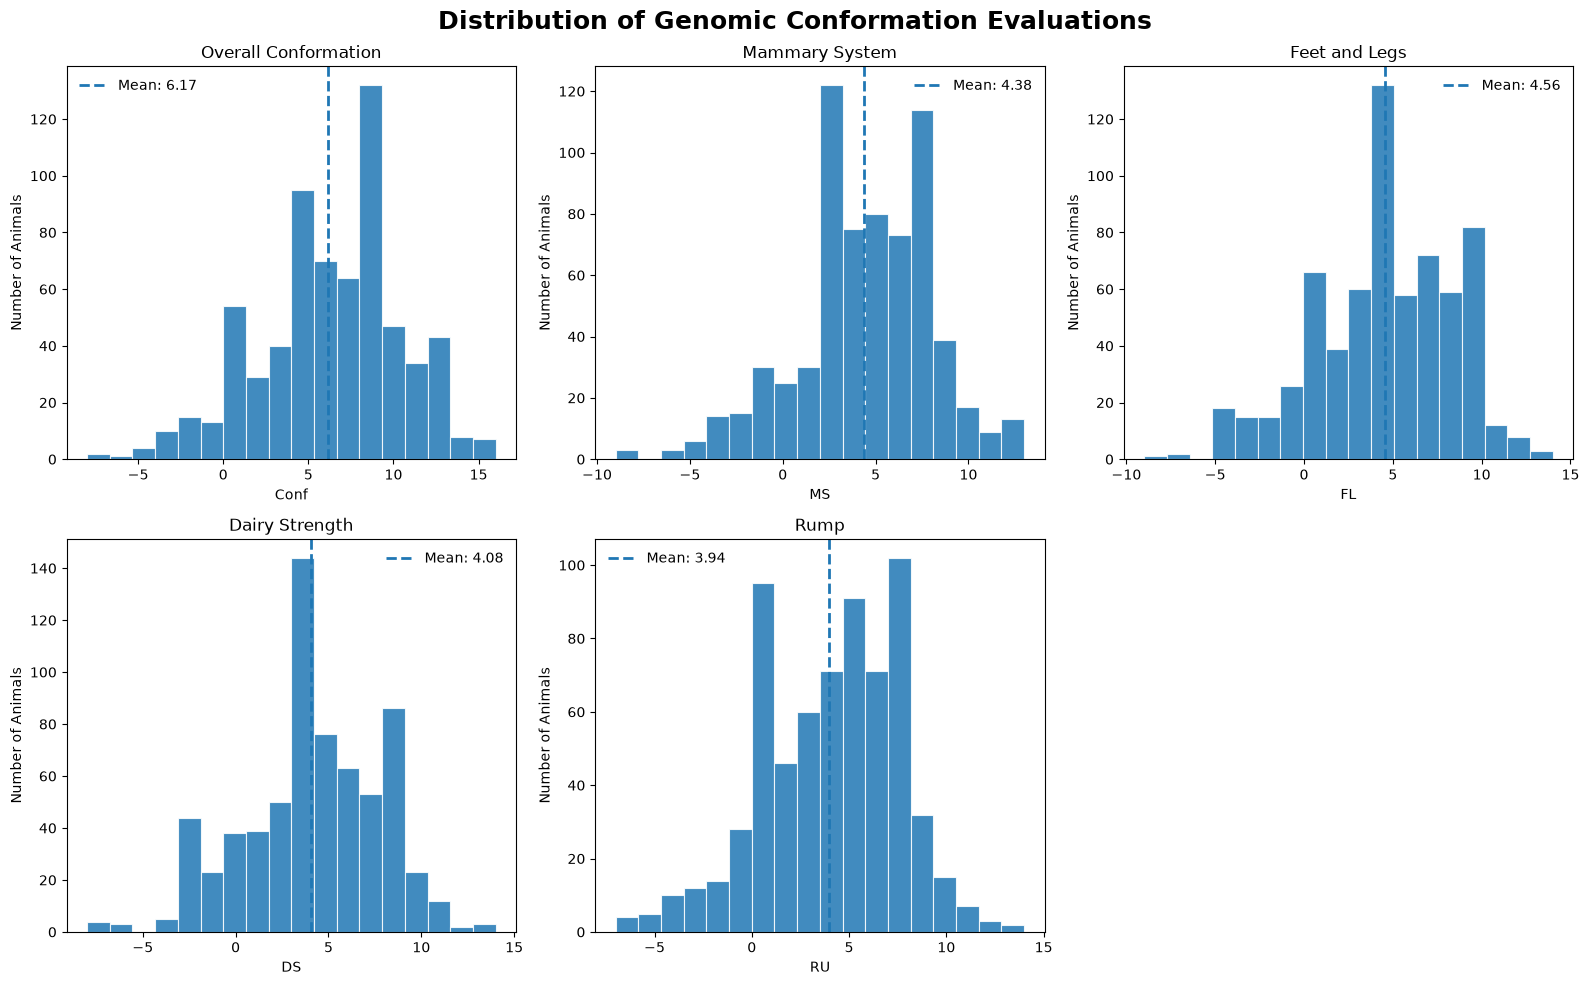

In [24]:
# ============================================================
# CONFORMATION TRAIT DISTRIBUTIONS
# ============================================================

conformation_traits = {
    "Overall Conformation": "Conf",
    "Mammary System": "MS",
    "Feet and Legs": "FL",
    "Dairy Strength": "DS",
    "Rump": "RU"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, (trait_name, column) in zip(
    axes,
    conformation_traits.items()
):

    values = df[column].dropna()

    ax.hist(
        values,
        bins=18,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85
    )

    mean_value = values.mean()

    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )

    ax.set_title(trait_name)
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Animals")
    ax.legend(frameon=False)

# Remove the unused sixth panel
axes[-1].axis("off")

fig.suptitle(
    "Distribution of Genomic Conformation Evaluations",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_trend_lines(df, year_col, traits, title, ylabel, labels=None, save=None):
    """Líneas de promedio por año. df, year_col, y lista de columnas 'traits'."""
    labels = labels or {t: t for t in traits}
    colors  = ['#1F3A5F', '#00B4D8', '#F77F00', '#6A0572', '#8D99AE',
               '#E63946', '#2A9D8F', '#FFB703']
    markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '*']
    styles  = ['-', '-', '-', '--', '--', '-', '--', '-']

    g = df.groupby(year_col)[traits].mean().sort_index()

    fig, ax = plt.subplots(figsize=(13, 7))
    for i, t in enumerate(traits):
        ax.plot(g.index, g[t], marker=markers[i % 8], linestyle=styles[i % 8],
                linewidth=2.6, markersize=7, color=colors[i % 8],
                label=labels.get(t, t))

    ax.set_title(title, fontsize=15, fontweight='bold', pad=14)
    ax.set_xlabel(year_col.title(), fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, color='#D9D9D9', linewidth=0.9, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Traits', bbox_to_anchor=(1.02, 1), loc='upper left',
              frameon=True, fontsize=10)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    return fig, ax

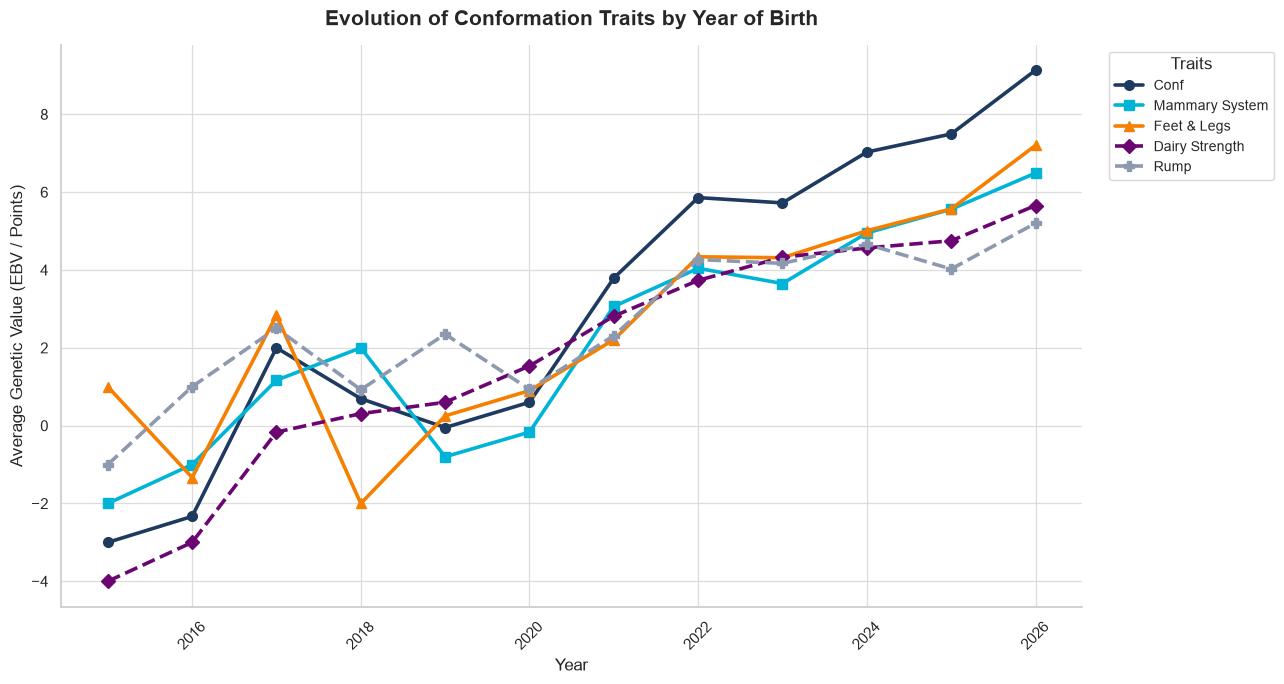

(<Figure size 1300x700 with 1 Axes>,
 <Axes: title={'center': 'Evolution of Conformation Traits by Year of Birth'}, xlabel='Year', ylabel='Average Genetic Value (EBV / Points)'>)

In [34]:
# preparar: asegúrate de tener columna 'year' y las variables en numérico
df['year'] = pd.to_datetime(df['Birth Date'], errors='coerce').dt.year
for c in ['Conf', 'MS', 'FL', 'DS', 'RU']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

plot_trend_lines(
    df[df['year'] >= 2015], 'year',
    traits=['Conf', 'MS', 'FL', 'DS', 'RU'],
    title='Evolution of Conformation Traits by Year of Birth',
    ylabel='Average Genetic Value (EBV / Points)',
    labels={'Conf': 'Conf', 'MS': 'Mammary System', 'FL': 'Feet & Legs',
            'DS': 'Dairy Strength', 'RU': 'Rump'},
    save='outputs/04_conformation_trend.png')

C:\Users\arincon\AppData\Local\Temp\ipykernel_38696\1616659287.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Age"] = (pd.Timestamp.today() - df["Birth Date"]).dt.days / 365.25


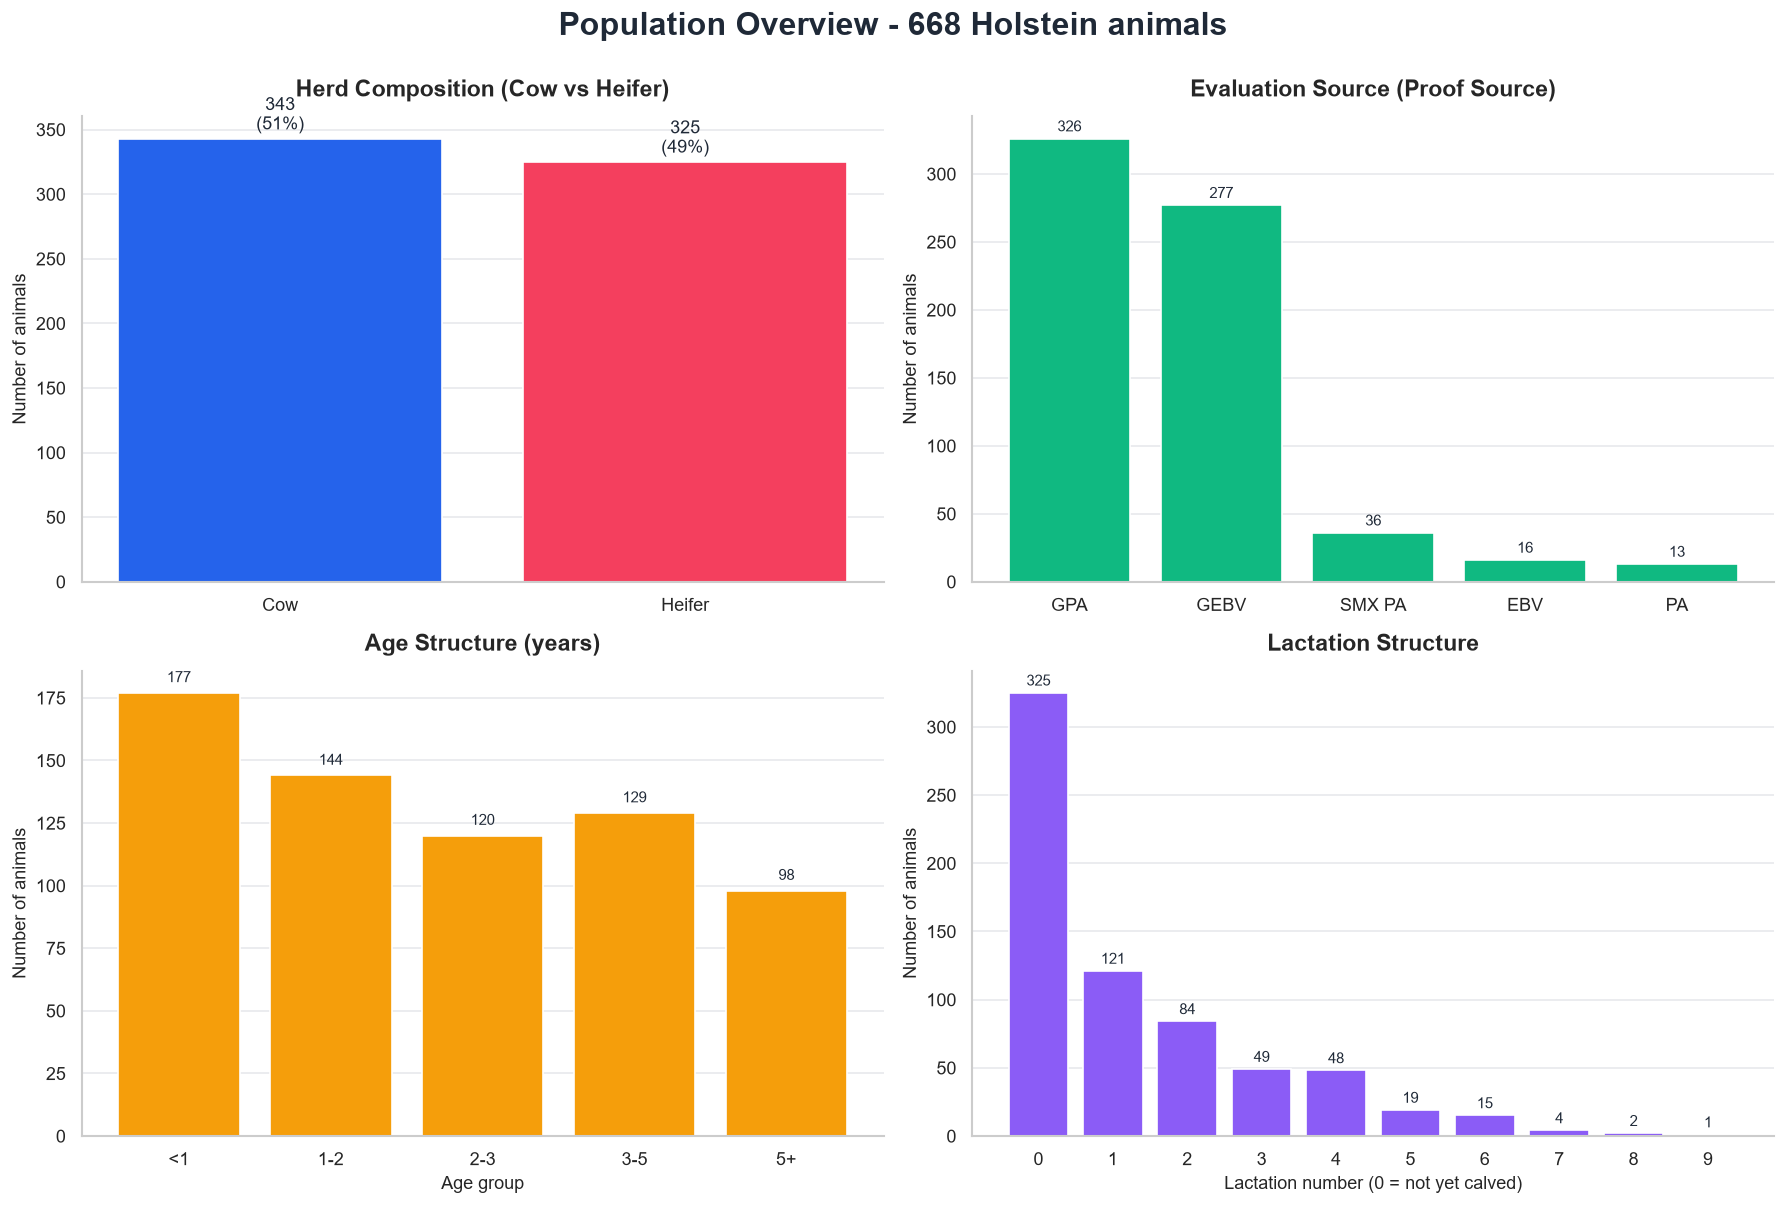

POPULATION CHARACTERISTICS
Total animals   : 668
Birth years     : 2013 - 2026
Type            : {'Cow': 343, 'Heifer': 325}
Age (years)     : mean=2.6, median=2.1
Proof Source    : {'GPA': 326, 'GEBV': 277, 'SMX PA': 36, 'EBV': 16, 'PA': 13}
Genotyped       : {'Y': 603, 'N': 65}
Heifers (lact=0): 325 | Cows (lact>=1): 343


In [37]:
# =====================================================================
# EDA - POPULATION CHARACTERISTICS  (self-contained, English titles)
# Answers: "What are the main characteristics of the population under study?"
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)

# ---- Style (inline, no external module needed) ----
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "figure.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#E5E7EB",
    "grid.alpha": 0.9, "axes.axisbelow": True, "font.size": 10.5,
})
BLUE, ROSE, GREEN, AMBER, VIOLET, INK = "#2563EB","#F43F5E","#10B981","#F59E0B","#8B5CF6","#1F2937"

def label_bars(ax, bars, fmt="{:.0f}", pad=3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+pad, fmt.format(h),
                ha="center", va="bottom", fontsize=9, color=INK)

# ---- 1. LOAD ----
df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
N = len(df)
df["Birth Date"] = pd.to_datetime(df["Birth Date"], errors="coerce")
df["Age"] = (pd.Timestamp.today() - df["Birth Date"]).dt.days / 365.25

# ---- 2. FIGURE: 4 population characteristics ----
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

t = df["Type"].value_counts()
b = ax[0,0].bar(t.index, t.values, color=[BLUE, ROSE], edgecolor="white")
ax[0,0].set_title("Herd Composition (Cow vs Heifer)"); ax[0,0].set_ylabel("Number of animals")
for bar in b:
    h = bar.get_height()
    ax[0,0].text(bar.get_x()+bar.get_width()/2, h+3, f"{int(h)}\n({h/N*100:.0f}%)",
                 ha="center", va="bottom", color=INK)

p = df["Proof Source"].value_counts()
b = ax[0,1].bar(p.index, p.values, color=GREEN, edgecolor="white")
ax[0,1].set_title("Evaluation Source (Proof Source)"); ax[0,1].set_ylabel("Number of animals")
label_bars(ax[0,1], b)

bins=[0,1,2,3,5,20]; labels=["<1","1-2","2-3","3-5","5+"]
ageg = pd.cut(df["Age"], bins=bins, labels=labels, right=False).value_counts().reindex(labels)
b = ax[1,0].bar(ageg.index.astype(str), ageg.values, color=AMBER, edgecolor="white")
ax[1,0].set_title("Age Structure (years)"); ax[1,0].set_xlabel("Age group"); ax[1,0].set_ylabel("Number of animals")
label_bars(ax[1,0], b)

lac = df["Lact. Number"].dropna().astype(int).value_counts().sort_index()
b = ax[1,1].bar(lac.index.astype(str), lac.values, color=VIOLET, edgecolor="white")
ax[1,1].set_title("Lactation Structure"); ax[1,1].set_xlabel("Lactation number (0 = not yet calved)"); ax[1,1].set_ylabel("Number of animals")
label_bars(ax[1,1], b)

fig.suptitle(f"Population Overview - {N} Holstein animals", fontsize=19, fontweight="bold", color=INK, y=1.0)
plt.tight_layout()
plt.savefig("outputs/EDA_population_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 3. PRINT NUMBERS to write the answer ----
print("="*60); print("POPULATION CHARACTERISTICS"); print("="*60)
print(f"Total animals   : {N}")
print(f"Birth years     : {int(df['Birth Date'].dt.year.min())} - {int(df['Birth Date'].dt.year.max())}")
print(f"Type            : {df['Type'].value_counts().to_dict()}")
print(f"Age (years)     : mean={df['Age'].mean():.1f}, median={df['Age'].median():.1f}")
print(f"Proof Source    : {df['Proof Source'].value_counts().to_dict()}")
print(f"Genotyped       : {df['Genotyped'].value_counts().to_dict()}")
print(f"Heifers (lact=0): {int((df['Lact. Number']==0).sum())} | Cows (lact>=1): {int((df['Lact. Number']>=1).sum())}")

### What are the main characteristics of the population under study?

The database contains **668 Holstein animals** born between **2013 and 2026**,
split almost evenly between **343 cows (51%)** and **325 heifers (49%)**. The
population is young (median age **2.1 years**): all **325 heifers** have lactation
number 0 (not yet calved), while the **343 cows** carry one or more lactations.

Genetic evaluations come mostly from **genomic sources** — **326 GPA** and
**277 GEBV** — with smaller groups from parent average (**SMX PA 36, PA 13**) and
**EBV (16)**. In total, **603 of 668 animals (90%) are genotyped**.

**Summary:** a young, genomically-evaluated commercial Holstein herd, balanced
between milking cows and replacement heifers.

In [39]:
# =====================================================================
# EDA - GENOMIC CHARACTERIZATION OF THE HOLSTEIN HERD
# Describe genomic breeding values + genetic markers before statistics
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "figure.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.alpha": 0.9,
    "axes.axisbelow": True, "font.size": 10.5,
})
TEAL, INK = "#06B6D4", "#1F2937"

# ---- 1. LOAD ----
df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]

# ---- 2. DESCRIPTIVE STATS OF GENOMIC BREEDING VALUES ----
genomic_traits = ["LPI", "Pro$", "Client Index",
                  "Milk (kg)", "Fat (kg)", "%Fat", "Prot (kg)", "%Prot",
                  "SCS", "HL", "Conf", "MS", "FL", "DS", "RU",
                  "Genomic Inb. %", "HO%"]
present = [c for c in genomic_traits if c in df.columns]     # avoid KeyError
for c in present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

summary = df[present].describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary = summary.rename(columns={"50%": "median"}).round(2)
summary["missing"] = len(df) - summary["count"].astype(int)
print("="*70); print("GENOMIC BREEDING VALUES - DESCRIPTIVE STATISTICS"); print("="*70)
print(summary.to_string())
summary.to_csv("outputs/genomic_summary_stats.csv")

# ---- 3. GENETIC MARKERS / HAPLOTYPES (auto-detect coding) ----
marker_cols = [c for c in df.columns if any(k in c.lower() for k in
               ["blad", "cvm", "dumps", "brachy", "hh", "haplo",
                "a2", "casein", "lacto", "beta", "kappa"])]

print("\n" + "="*70); print("GENETIC MARKERS - COMPOSITION"); print("="*70)
freq_rows = {}
for c in marker_cols:
    s = df[c].dropna()
    if s.empty:
        continue
    if pd.api.types.is_numeric_dtype(pd.to_numeric(s, errors="coerce")) and \
       pd.to_numeric(s, errors="coerce").notna().all():
        v = pd.to_numeric(s, errors="coerce")            # numeric = carrier prob.
        print(f"{c:22s} (numeric)  mean={v.mean():.2f}  max={v.max():.2f}  n={len(v)}")
        freq_rows[c] = v.mean()
    else:
        vc = s.astype(str).value_counts()                # categorical = codes
        print(f"{c:22s} (coded)   {vc.to_dict()}")



GENOMIC BREEDING VALUES - DESCRIPTIVE STATISTICS
                count     mean     std      min   median      max  missing
LPI             668.0  3243.24  285.20  2300.00  3260.50  3902.00        0
Pro$            668.0  1145.09  733.44 -1528.00  1215.00  3027.00        0
Client Index    668.0  3243.24  285.20  2300.00  3260.50  3902.00        0
Milk (kg)       668.0   412.37  536.77 -1742.00   416.00  1921.00        0
Fat (kg)        668.0    42.54   33.04   -62.00    47.00   160.00        0
%Fat            668.0     0.22    0.30    -0.87     0.22     1.29        0
Prot (kg)       668.0    26.05   20.24   -38.00    28.00    88.00        0
%Prot           668.0     0.09    0.14    -0.40     0.10     0.53        0
SCS             668.0   101.70    3.47    92.00   102.00   111.00        0
HL              668.0   102.53    3.71    91.00   103.00   112.00        0
Conf            668.0     6.17    4.15    -8.00     7.00    16.00        0
MS              668.0     4.38    3.65    -9.00    

### Describe the genomic and demographic characteristics of the Holstein herd

**Demographic (see previous question):** 668 Holstein animals born 2013–2026,
343 cows (51%) and 325 heifers (49%), median age 2.1 years, 90% genotyped.

**Genomic breeding values.** For the selection indexes, the herd averages
**LPI ≈ 3,243** (median 3,260) and **Pro$ ≈ 1,145** (median 1,215). Genomic
production evaluations average **Milk +412 kg, Fat +42.5 kg, Protein +26 kg**
(these are parental/genomic evaluations, not measured production).

**Genomic inbreeding.** Available for 489 of 668 animals, with a mean of
**12.3%**; **over 90% of evaluated animals sit at ≥8%**, indicating a high and
management-relevant level of genomic inbreeding.

**Genetic markers.** Carrier status was screened for recessive defects
(BLAD, CVM, …) and haplotypes (HH1–HH6): [FILL WITH YOUR OUTPUT — e.g. HH5 mean X%].
Milk-protein genotypes (A2, kappa-casein, β-lactoglobulin): [FILL FROM OUTPUT].

**Summary:** a young, highly-genotyped commercial Holstein herd with strong
selection indexes but a notably high genomic-inbreeding level that warrants
mating management.

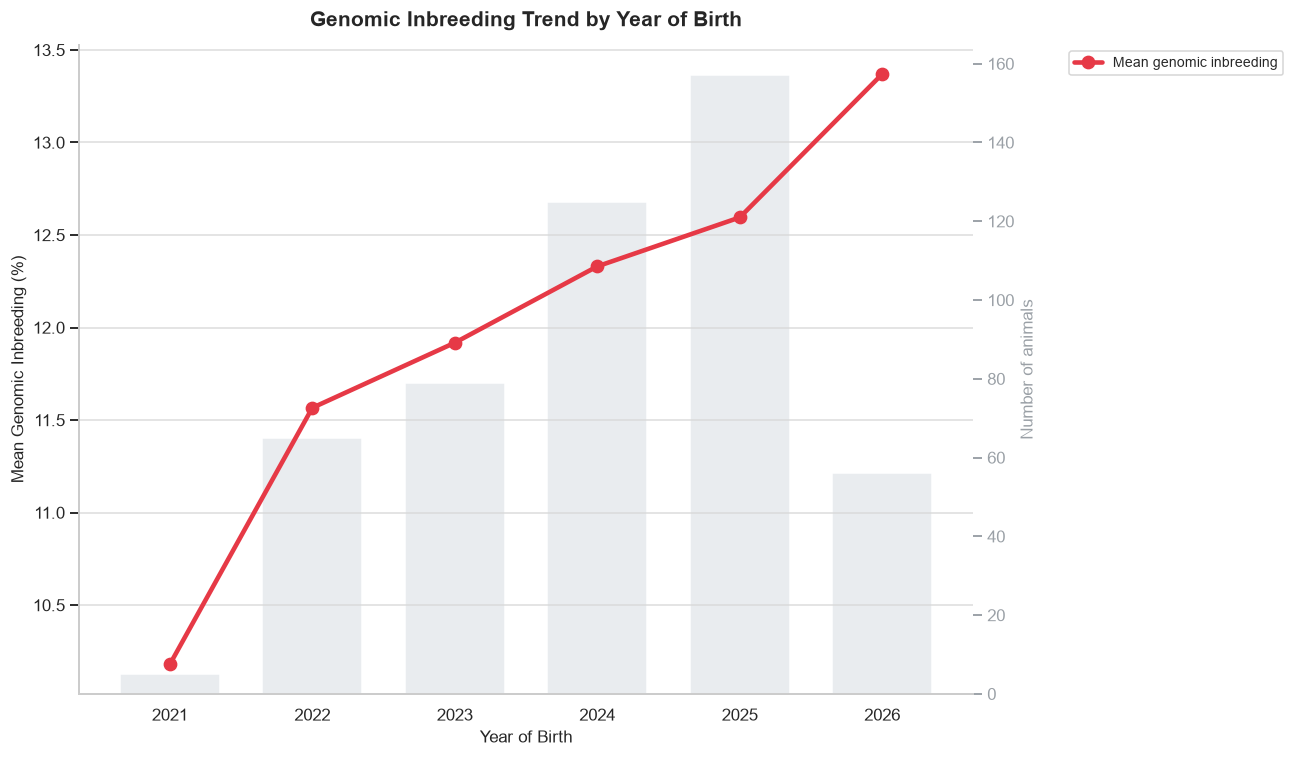

In [44]:
# =====================================================================
# GENOMIC INBREEDING TREND by year of birth (standalone, line style)
# =====================================================================
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight","figure.facecolor":"white",
 "axes.titlesize":14,"axes.titleweight":"bold","axes.spines.top":False,
 "axes.grid":True,"grid.color":"#E5E7EB","grid.alpha":0.9,"axes.axisbelow":True,"font.size":10.5})

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
df["year"] = pd.to_datetime(df["Birth Date"], errors="coerce").dt.year
df["Genomic Inb. %"] = pd.to_numeric(df["Genomic Inb. %"], errors="coerce")

# keep only cohorts that actually have inbreeding data
sub      = df[(df["year"] >= 2021) & (df["Genomic Inb. %"].notna())]
counts   = sub.groupby("year").size()
mean_inb = sub.groupby("year")["Genomic Inb. %"].mean()

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values, color="#E9ECEF", width=0.7, zorder=0)   # cohort size
ax2.set_ylabel("Number of animals", color="#9AA0A6")
ax2.tick_params(axis="y", colors="#9AA0A6"); ax2.grid(False)

ax1.plot(mean_inb.index, mean_inb.values, marker="o", ls="-", lw=3, ms=8,
         color="#E63946", zorder=3, label="Mean genomic inbreeding")
ax1.set_zorder(ax2.get_zorder() + 1); ax1.patch.set_visible(False)

ax1.set_title("Genomic Inbreeding Trend by Year of Birth")
ax1.set_xlabel("Year of Birth"); ax1.set_ylabel("Mean Genomic Inbreeding (%)")
ax1.grid(True, axis="y", color="#D9D9D9", alpha=0.9)
ax1.legend(bbox_to_anchor=(1.10, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/inbreeding_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Haplotypes included: ['HH1', 'HH2', 'HH3', 'HH4', 'HH5', 'HH6', 'HCD', 'HMW']


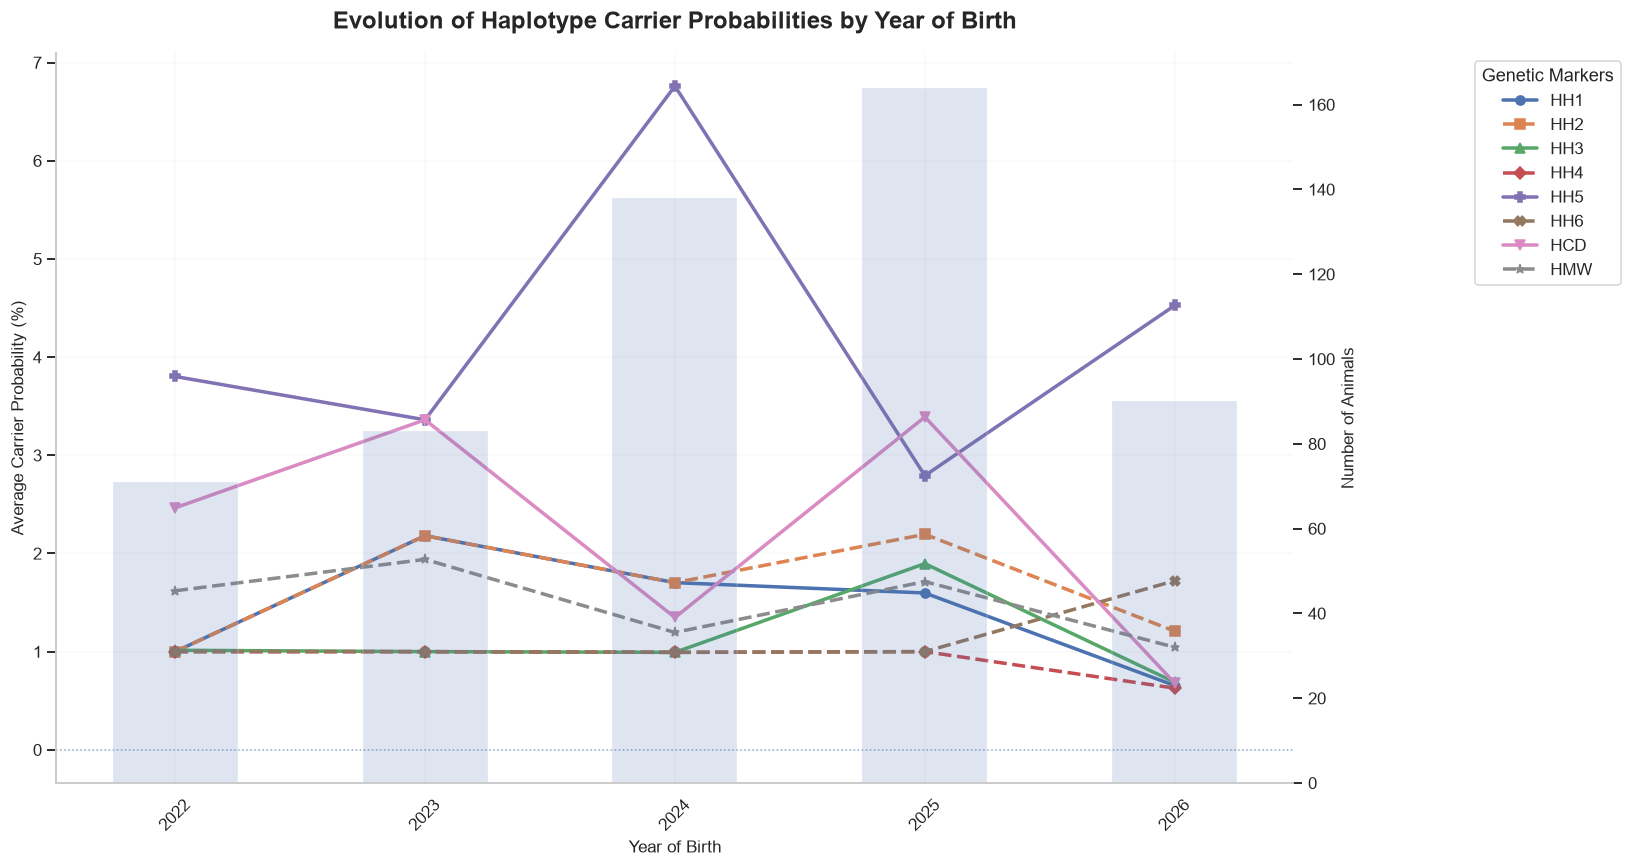

In [45]:
# ============================================================
# HAPLOTYPE CARRIER PROBABILITY TRENDS BY YEAR OF BIRTH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

haplotypes = [
    "HH1",
    "HH2",
    "HH3",
    "HH4",
    "HH5",
    "HH6",
    "HCD",
    "HMW"
]

# Keep only haplotype columns that exist in the dataset
available_haplotypes = [
    column for column in haplotypes
    if column in df.columns
]

print("Haplotypes included:", available_haplotypes)

# Convert values to numeric
for column in available_haplotypes:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Make sure year is numeric
df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

# Calculate average carrier probability by birth year
haplotype_trend = (
    df.groupby("year")[available_haplotypes]
      .mean()
      .sort_index()
)

# Number of animals represented in each year
cohort_size = (
    df.groupby("year")
      .size()
      .reindex(haplotype_trend.index)
)

# Optional: restrict to recent cohorts
# Remove this filter if you want to include all years
start_year = 2022

haplotype_trend = haplotype_trend[
    haplotype_trend.index >= start_year
]

cohort_size = cohort_size[
    cohort_size.index >= start_year
]

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 8))

# Secondary axis for cohort size
ax2 = ax1.twinx()

# Grey background bars: number of animals per year
ax2.bar(
    cohort_size.index,
    cohort_size.values,
    width=0.50,
    alpha=0.18,
    label="Animals in cohort",
    zorder=1
)

ax2.set_ylabel(
    "Number of Animals",
    fontsize=11
)

ax2.grid(False)

# Markers and line styles
markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
line_styles = ["-", "--", "-", "--", "-", "--", "-", "--"]

# Plot each haplotype
for column, marker, line_style in zip(
    available_haplotypes,
    markers,
    line_styles
):
    ax1.plot(
        haplotype_trend.index,
        haplotype_trend[column],
        marker=marker,
        linestyle=line_style,
        linewidth=2.3,
        markersize=6,
        label=column,
        zorder=3
    )

ax1.set_title(
    "Evolution of Haplotype Carrier Probabilities by Year of Birth",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax1.set_xlabel(
    "Year of Birth",
    fontsize=11
)

ax1.set_ylabel(
    "Average Carrier Probability (%)",
    fontsize=11
)

ax1.axhline(
    0,
    linewidth=1,
    linestyle=":",
    alpha=0.6
)

ax1.set_xticks(haplotype_trend.index)
ax1.tick_params(axis="x", rotation=45)

ax1.legend(
    title="Genetic Markers",
    bbox_to_anchor=(1.14, 1),
    loc="upper left",
    frameon=True
)

ax1.grid(
    axis="both",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# IDENTIFY SIRE-RELATED COLUMNS
# ============================================================

sire_columns = [
    column
    for column in df.columns
    if "SIRE" in str(column).upper()
]

print(sire_columns)

['Sire Semen Code', 'Sire Reg Number', 'Sire Name', 'Original Sire Semen Code', 'Original Sire Reg Number', 'Original Sire Name']


In [53]:
sire_reg_col = "Sire Reg Number"
sire_name_col = "Sire Name"

In [54]:
sire_reg_col = "Sire Reg Number"
sire_name_col = "Sire Name"

In [55]:
# ============================================================
# PREPARE SIRE IDENTIFIERS
# ============================================================

sire_df = df[
    [
        sire_reg_col,
        sire_name_col,
        "Registration Number",
        "year",
        "Genomic Inb. %"
    ]
].copy()

# Standardize registration numbers
sire_df[sire_reg_col] = (
    sire_df[sire_reg_col]
    .astype("string")
    .str.strip()
)

# Standardize names only for display
sire_df[sire_name_col] = (
    sire_df[sire_name_col]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Remove animals without a usable sire registration number
invalid_sire_values = ["", "NAN", "NONE", "<NA>"]

sire_df = sire_df[
    sire_df[sire_reg_col].notna()
    & ~sire_df[sire_reg_col].str.upper().isin(invalid_sire_values)
].copy()

print(f"Animals with a valid sire registration number: {len(sire_df)}")
print(f"Unique sires: {sire_df[sire_reg_col].nunique()}")

Animals with a valid sire registration number: 666
Unique sires: 212


In [56]:
# ============================================================
# OFFSPRING COUNT PER SIRE REGISTRATION NUMBER
# ============================================================

sire_counts = (
    sire_df
    .groupby(sire_reg_col)
    .agg(
        Offspring=("Registration Number", "count"),
        Sire_Name=(
            sire_name_col,
            lambda values: values.mode().iloc[0]
            if not values.mode().empty
            else "UNKNOWN"
        )
    )
    .reset_index()
    .sort_values("Offspring", ascending=False)
)

total_animals = sire_counts["Offspring"].sum()

sire_counts["Share_%"] = (
    sire_counts["Offspring"] / total_animals * 100
)

display(sire_counts.head(20))

,Sire Reg Number,Offspring,Sire_Name,Share_%
4,HO840M3125993715,37,DELTA-LAMBDA,5.555556
165,HOCANM14259316,27,ANAHITA,4.054054
62,HO840M3234629819,26,BULLSEYE,3.903904
199,HONLDM688600952,21,RANGER-RED,3.153153
176,HOCANM14646030,19,ZEUS,2.852853
161,HOCANM14227002,18,AMBROSE *RC,2.702703
39,HO840M3200059526,14,JOHNBOY,2.102102
153,HOCANM14131698,11,ZIRCON-P,1.651652
99,HOCANM120461050,10,LEMAGIC,1.501502
182,HOCANM14766540,9,BRIGHTPATH,1.351351


In [57]:
# ============================================================
# VERIFY SIRE-DIVERSITY CLAIMS
# ============================================================

number_unique_sires = sire_counts[sire_reg_col].nunique()

top_sire = sire_counts.iloc[0]

top_10_offspring = sire_counts.head(10)["Offspring"].sum()
top_10_share = top_10_offspring / total_animals * 100

print(f"Total animals represented: {total_animals}")
print(f"Unique sires: {number_unique_sires}")

print("\nTop sire:")
print(f"Name: {top_sire['Sire_Name']}")
print(f"Registration number: {top_sire[sire_reg_col]}")
print(f"Offspring: {int(top_sire['Offspring'])}")
print(f"Share of animals: {top_sire['Share_%']:.1f}%")

print("\nTop 10 sires:")
print(f"Offspring: {int(top_10_offspring)}")
print(f"Share of animals: {top_10_share:.1f}%")

Total animals represented: 666
Unique sires: 212

Top sire:
Name: DELTA-LAMBDA
Registration number: HO840M3125993715
Offspring: 37
Share of animals: 5.6%

Top 10 sires:
Offspring: 192
Share of animals: 28.8%


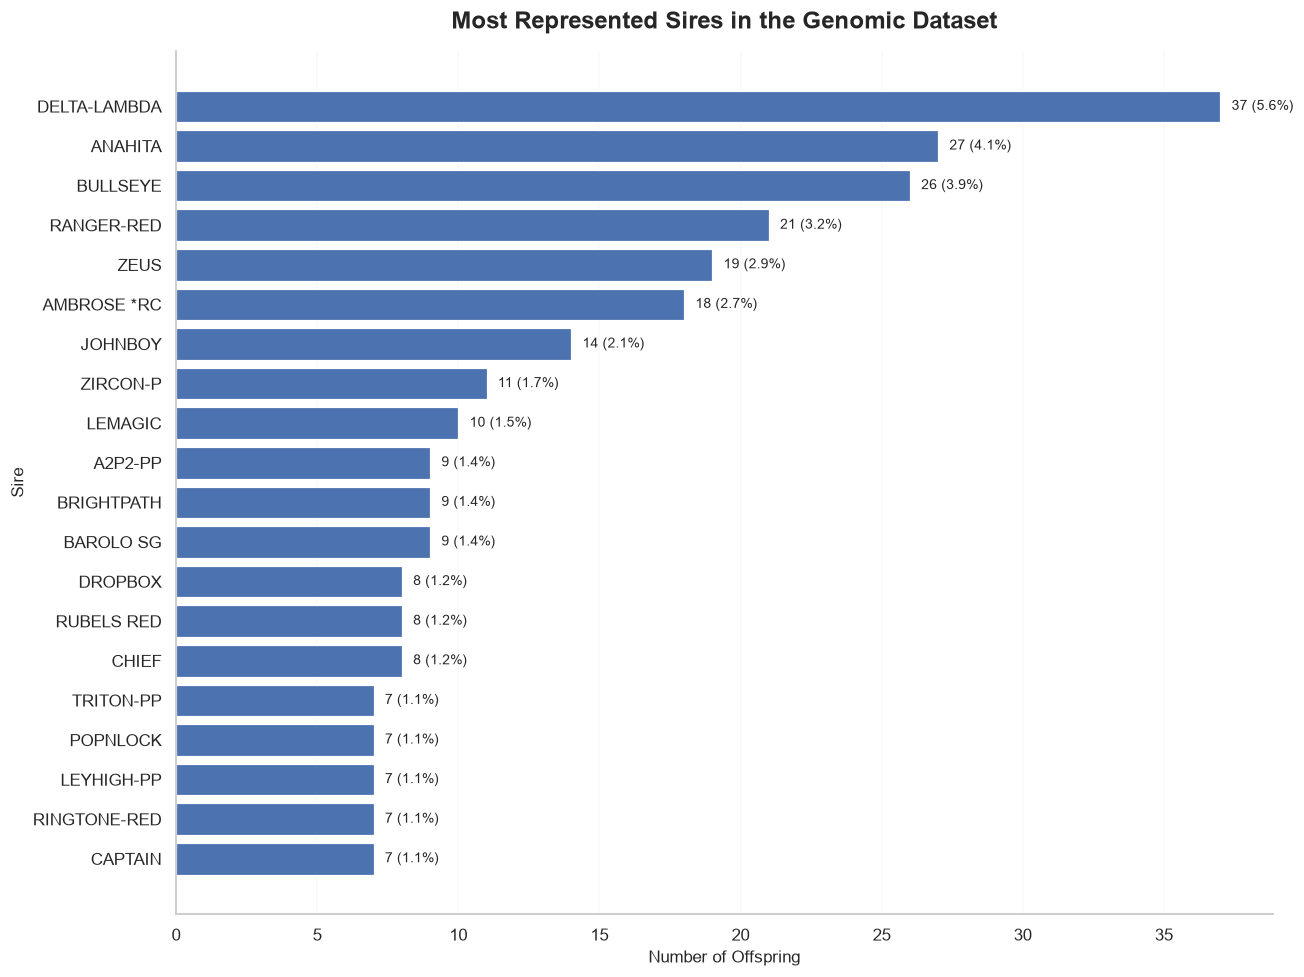

In [58]:
# ============================================================
# TOP 20 SIRES BY NUMBER OF OFFSPRING
# ============================================================

top_20 = sire_counts.head(20).sort_values(
    "Offspring",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top_20["Sire_Name"],
    top_20["Offspring"],
    edgecolor="white",
    linewidth=0.8
)

ax.set_title(
    "Most Represented Sires in the Genomic Dataset",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Offspring")
ax.set_ylabel("Sire")

for bar, share in zip(bars, top_20["Share_%"]):
    width = bar.get_width()

    ax.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)} ({share:.1f}%)",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SIRE CONCENTRATION METRICS
#Herfindahl–Hirschman Index.
# ============================================================

sire_shares = (
    sire_counts["Offspring"] / sire_counts["Offspring"].sum()
)

hhi = (sire_shares ** 2).sum()
hhi_10000 = hhi * 10000

effective_number_of_sires = 1 / hhi

top_1_share = sire_shares.iloc[:1].sum() * 100
top_5_share = sire_shares.iloc[:5].sum() * 100
top_10_share = sire_shares.iloc[:10].sum() * 100
top_20_share = sire_shares.iloc[:20].sum() * 100

print(f"Top 1 share: {top_1_share:.1f}%")
print(f"Top 5 share: {top_5_share:.1f}%")
print(f"Top 10 share: {top_10_share:.1f}%")
print(f"Top 20 share: {top_20_share:.1f}%")
print(f"HHI: {hhi_10000:.1f}")
print(f"Effective number of sires: {effective_number_of_sires:.1f}")

Top 1 share: 5.6%
Top 5 share: 19.5%
Top 10 share: 28.8%
Top 20 share: 40.4%
HHI: 139.1
Effective number of sires: 71.9


In [60]:
# ============================================================
# SIRE DIVERSITY BY BIRTH-YEAR COHORT
# ============================================================

def cohort_sire_metrics(group):
    counts = group[sire_reg_col].value_counts()
    shares = counts / counts.sum()

    return pd.Series({
        "Animals": len(group),
        "Unique_Sires": counts.size,
        "Top_Sire_Share_%": shares.iloc[0] * 100,
        "Top_10_Share_%": shares.iloc[:10].sum() * 100,
        "HHI": (shares ** 2).sum() * 10000,
        "Effective_Sires": 1 / (shares ** 2).sum()
    })


sire_diversity_year = (
    sire_df
    .dropna(subset=["year"])
    .groupby("year")
    .apply(cohort_sire_metrics, include_groups=False)
    .reset_index()
    .sort_values("year")
)

display(sire_diversity_year)

,year,Animals,Unique_Sires,Top_Sire_Share_%,Top_10_Share_%,HHI,Effective_Sires
0,2013,1.0,1.0,100.000000,100.000000,10000.000000,1.000000
1,2015,1.0,1.0,100.000000,100.000000,10000.000000,1.000000
2,2016,3.0,3.0,33.333333,100.000000,3333.333333,3.000000
3,2017,6.0,6.0,16.666667,100.000000,1666.666667,6.000000
4,2018,13.0,9.0,15.384615,100.000000,1242.603550,8.047619
5,2019,20.0,16.0,10.000000,70.000000,700.000000,14.285714
6,2020,30.0,20.0,16.666667,66.666667,711.111111,14.062500
7,2021,48.0,26.0,10.416667,66.666667,625.000000,16.000000
8,2022,71.0,31.0,16.901408,66.197183,716.127752,13.963989
9,2023,83.0,30.0,15.662651,66.265060,622.731891,16.058275


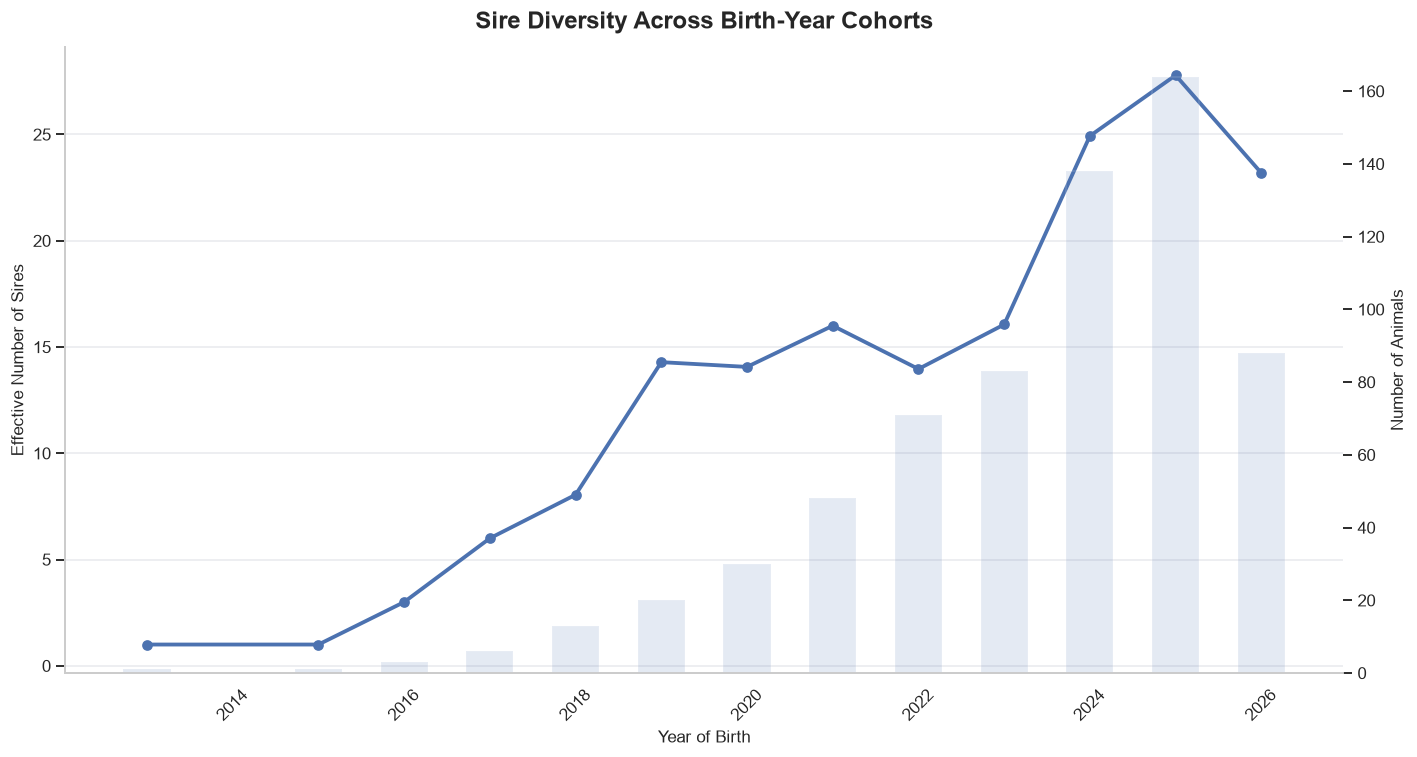

In [61]:
# ============================================================
# EFFECTIVE NUMBER OF SIRES OVER TIME
# ============================================================

fig, ax1 = plt.subplots(figsize=(13, 7))

ax1.plot(
    sire_diversity_year["year"],
    sire_diversity_year["Effective_Sires"],
    marker="o",
    linewidth=2.5,
    label="Effective number of sires"
)

ax1.set_xlabel("Year of Birth")
ax1.set_ylabel("Effective Number of Sires")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.bar(
    sire_diversity_year["year"],
    sire_diversity_year["Animals"],
    width=0.55,
    alpha=0.15,
    label="Animals in cohort"
)

ax2.set_ylabel("Number of Animals")
ax2.grid(False)

ax1.set_title(
    "Sire Diversity Across Birth-Year Cohorts",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# COMBINE SIRE CONCENTRATION AND GENOMIC INBREEDING
# ============================================================

inbreeding_year = (
    sire_df
    .dropna(subset=["year", "Genomic Inb. %"])
    .groupby("year")
    .agg(
        Mean_Genomic_Inbreeding=("Genomic Inb. %", "mean"),
        Median_Genomic_Inbreeding=("Genomic Inb. %", "median"),
        Inbreeding_Records=("Genomic Inb. %", "count")
    )
    .reset_index()
)

sire_inbreeding_trend = sire_diversity_year.merge(
    inbreeding_year,
    on="year",
    how="inner"
)

display(sire_inbreeding_trend)

,year,Animals,Unique_Sires,Top_Sire_Share_%,Top_10_Share_%,HHI,Effective_Sires,Mean_Genomic_Inbreeding,Median_Genomic_Inbreeding,Inbreeding_Records
0,2016,3.0,3.0,33.333333,100.000000,3333.333333,3.000000,6.500000,6.50,1
1,2017,6.0,6.0,16.666667,100.000000,1666.666667,6.000000,17.800000,17.80,1
2,2021,48.0,26.0,10.416667,66.666667,625.000000,16.000000,10.180000,9.10,5
3,2022,71.0,31.0,16.901408,66.197183,716.127752,13.963989,11.566154,11.60,65
4,2023,83.0,30.0,15.662651,66.265060,622.731891,16.058275,11.917722,12.30,79
5,2024,138.0,50.0,11.594203,50.000000,401.176223,24.926702,12.330400,11.40,125
6,2025,164.0,62.0,9.146341,48.170732,359.904819,27.785124,12.594904,12.60,157
7,2026,88.0,34.0,7.954545,55.681818,431.301653,23.185629,13.369643,13.45,56


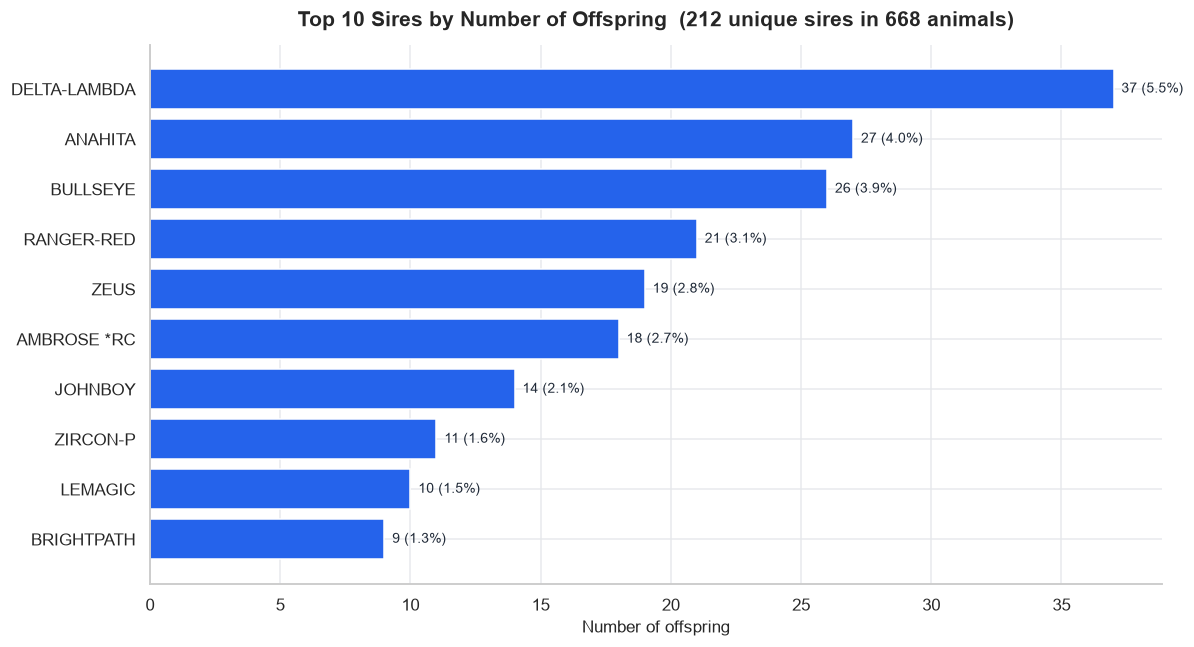

Unique sires (by Reg Number): 212
Top 10 sires cover 192 of 668 animals (28.7%)
Most used sire: DELTA-LAMBDA -> 37 offspring


In [46]:
# =====================================================================
# SIRE DIVERSITY - identified by unique registration number
# =====================================================================
import os, pandas as pd, matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"axes.titlesize":14,"axes.titleweight":"bold",
 "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
 "grid.color":"#E5E7EB","axes.axisbelow":True,"font.size":10.5})

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
N = len(df)

# unique ID = Sire Reg Number ; name only as label
sire = (df.groupby("Sire Reg Number")
          .agg(animals=("Sire Reg Number","size"), name=("Sire Name","first"))
          .sort_values("animals", ascending=False))

n_sires  = df["Sire Reg Number"].nunique()
top10    = sire.head(10)
top10_pc = top10["animals"].sum() / N * 100

fig, ax = plt.subplots(figsize=(11, 6))
b = ax.barh(top10["name"][::-1], top10["animals"][::-1], color="#2563EB", edgecolor="white")
for bar in b:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{int(w)} ({w/N*100:.1f}%)", va="center", fontsize=9, color="#1F2937")
ax.set_title(f"Top 10 Sires by Number of Offspring  ({n_sires} unique sires in {N} animals)")
ax.set_xlabel("Number of offspring"); ax.grid(True, axis="x")
plt.tight_layout(); plt.savefig("outputs/sire_diversity.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"Unique sires (by Reg Number): {n_sires}")
print(f"Top 10 sires cover {int(top10['animals'].sum())} of {N} animals ({top10_pc:.1f}%)")
print(f"Most used sire: {top10['name'].iloc[0]} -> {int(top10['animals'].iloc[0])} offspring")

The concentration of offspring among a limited number of sires represents a plausible contributor to genomic inbreeding. This hypothesis should be evaluated by examining whether sire-concentration metrics increased across birth-year cohorts in parallel with genomic inbreeding. Causality cannot be established without information on sire–dam genomic relationships and mating structure.

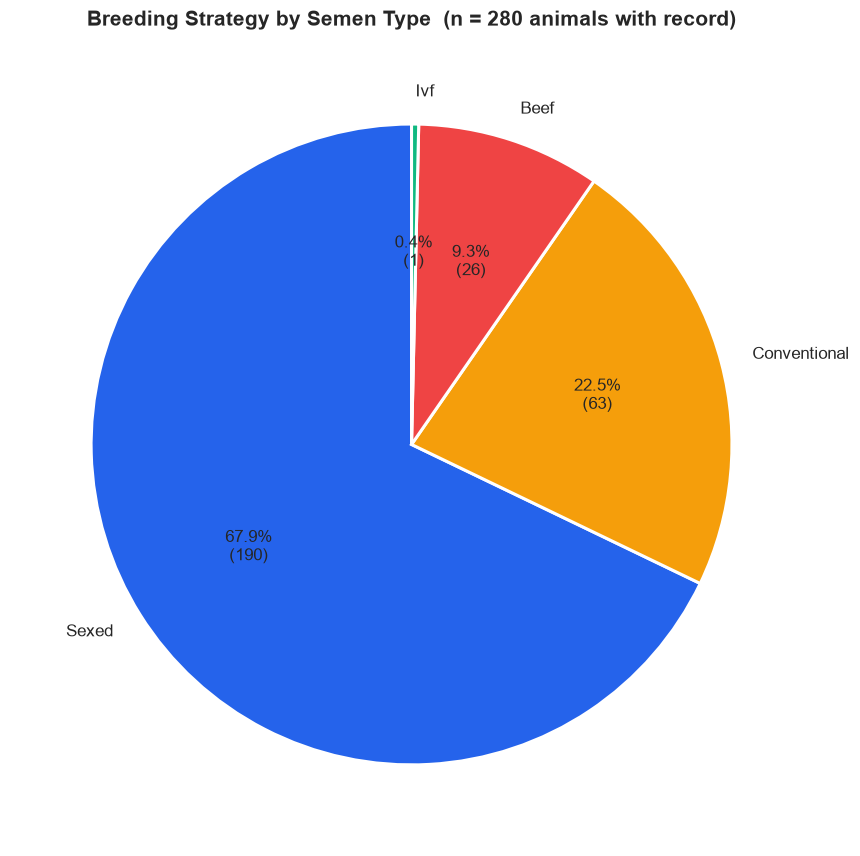

{'Sexed': 190, 'Conventional': 63, 'Beef': 26, 'Ivf': 1} | not recorded: 388


In [47]:
# =====================================================================
# BREEDING STRATEGY - semen type (pie chart)
# =====================================================================
import matplotlib.pyplot as plt, pandas as pd
grp = df["Current group"].value_counts()          # Sexed / Conventional / Beef / Ivf
colors = {"Sexed":"#2563EB","Conventional":"#F59E0B","Beef":"#EF4444","Ivf":"#10B981"}

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(grp.values, labels=grp.index, autopct=lambda p: f"{p:.1f}%\n({int(round(p*grp.sum()/100))})",
       colors=[colors.get(k, "#9CA3AF") for k in grp.index],
       startangle=90, wedgeprops={"edgecolor":"white","linewidth":2},
       textprops={"fontsize":11})
ax.set_title(f"Breeding Strategy by Semen Type  (n = {int(grp.sum())} animals with record)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/breeding_strategy_pie.png", dpi=150, bbox_inches="tight"); plt.show()
print(grp.to_dict(), f"| not recorded: {df['Current group'].isna().sum()}")

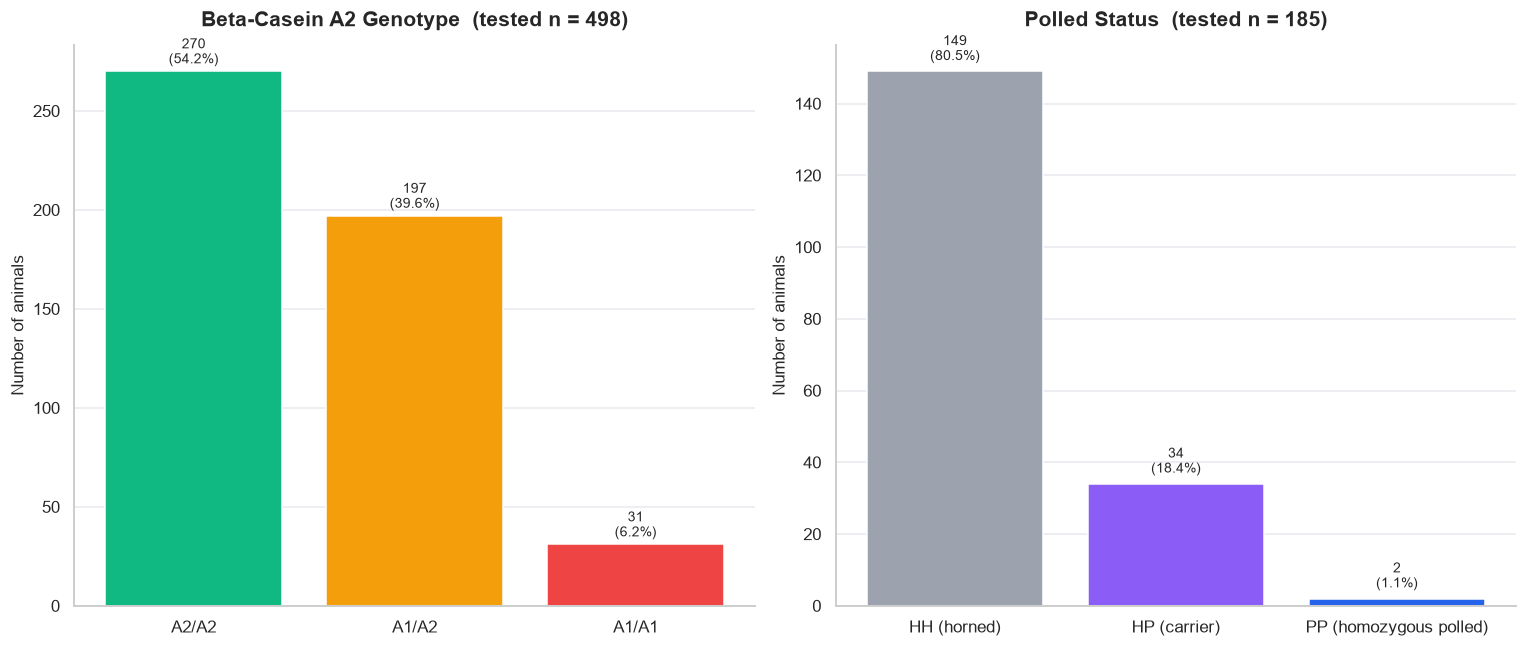

A2: {'A2/A2': 270, 'A1/A2': 197, 'A1/A1': 31} | untested: 170
Polled: {'HH': 149, 'HP': 34, 'PP': 2} | untested: 483


In [48]:
# =====================================================================
# MILK PROTEIN GENOTYPE (A2) AND POLLED STATUS
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

a2 = df["A2 Test"].value_counts()
tested_a2 = int(a2.sum())
b = ax[0].bar(a2.index, a2.values, color=["#10B981","#F59E0B","#EF4444"], edgecolor="white")
for bar in b:
    h = bar.get_height()
    ax[0].text(bar.get_x()+bar.get_width()/2, h+2, f"{int(h)}\n({h/tested_a2*100:.1f}%)",
               ha="center", va="bottom", fontsize=9)
ax[0].set_title(f"Beta-Casein A2 Genotype  (tested n = {tested_a2})")
ax[0].set_ylabel("Number of animals")

po = df["Polled Test"].value_counts()
tested_po = int(po.sum())
lbl = {"HH":"HH (horned)","HP":"HP (carrier)","PP":"PP (homozygous polled)"}
b = ax[1].bar([lbl.get(k,k) for k in po.index], po.values,
              color=["#9CA3AF","#8B5CF6","#2563EB"], edgecolor="white")
for bar in b:
    h = bar.get_height()
    ax[1].text(bar.get_x()+bar.get_width()/2, h+2, f"{int(h)}\n({h/tested_po*100:.1f}%)",
               ha="center", va="bottom", fontsize=9)
ax[1].set_title(f"Polled Status  (tested n = {tested_po})")
ax[1].set_ylabel("Number of animals")

plt.tight_layout(); plt.savefig("outputs/a2_polled.png", dpi=150, bbox_inches="tight"); plt.show()
print("A2:", a2.to_dict(), "| untested:", int(df["A2 Test"].isna().sum()))
print("Polled:", po.to_dict(), "| untested:", int(df["Polled Test"].isna().sum()))

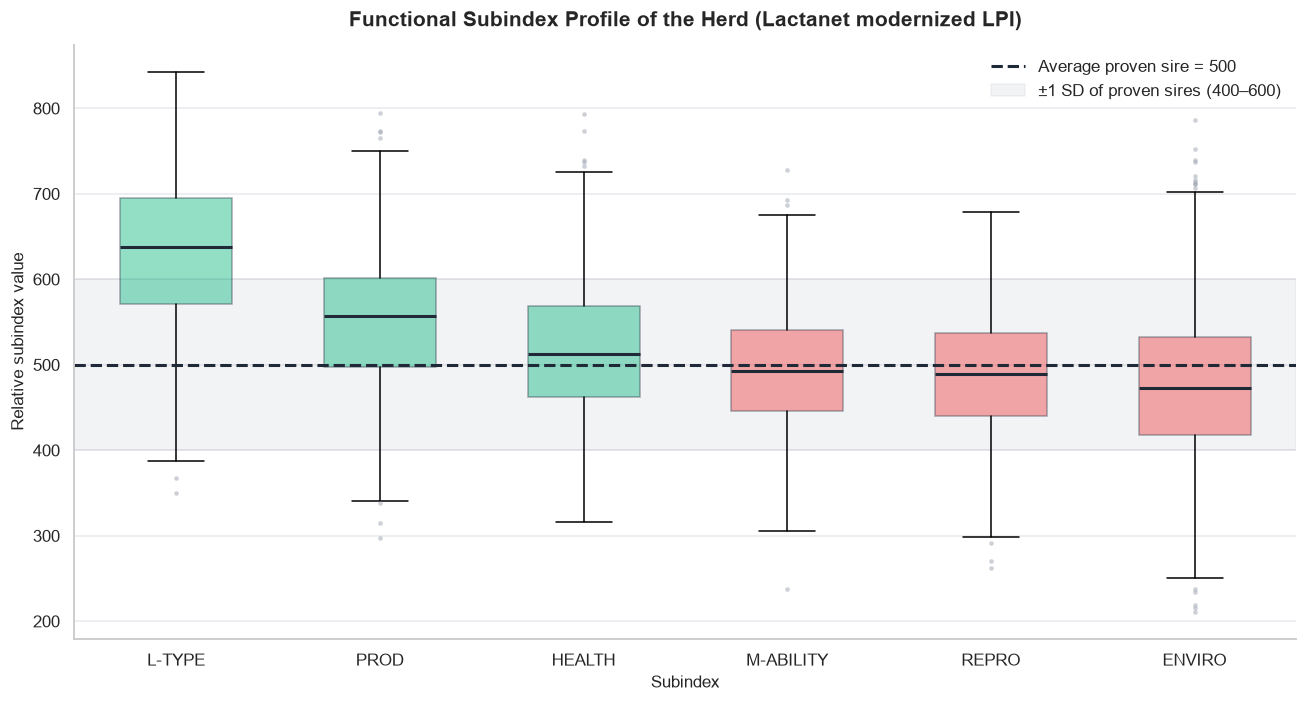

FUNCTIONAL SUBINDEXES - DESCRIPTIVE STATISTICS (base: proven sire = 500)
           count   mean  median   std    min    max
PROD       668.0  549.0   557.5  78.2  297.0  794.0
HEALTH     668.0  514.4   513.0  79.0  316.0  793.0
L-TYPE     668.0  629.5   638.0  85.6  350.0  843.0
REPRO      668.0  485.6   489.0  73.6  262.0  679.0
M-ABILITY  668.0  492.7   492.5  70.3  238.0  728.0
ENVIRO     668.0  476.6   473.0  90.8  211.0  786.0

Position vs proven-sire base (500):
  L-TYPE     median= 638.0  (ABOVE base)  |   92.1% of animals >= 500
  PROD       median= 557.5  (ABOVE base)  |   74.4% of animals >= 500
  HEALTH     median= 513.0  (ABOVE base)  |   55.8% of animals >= 500
  M-ABILITY  median= 492.5  (BELOW base)  |   46.7% of animals >= 500
  REPRO      median= 489.0  (BELOW base)  |   44.3% of animals >= 500
  ENVIRO     median= 473.0  (BELOW base)  |   36.8% of animals >= 500


In [67]:
# =====================================================================
# FUNCTIONAL SUBINDEX PROFILE - boxplot vs proven-sire base (500, SD=100)
# Source: Lactanet modernized LPI (April 2025): each subindex is standardized
# so the average proven sire = 500, with a standard deviation of 100.
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.bbox": "tight", "figure.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.alpha": 0.9,
    "axes.axisbelow": True, "font.size": 10.5,
})

# ---- 1. LOAD ----
df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]

# ---- 2. PREPARE SUBINDEXES ----
fi = ["PROD", "HEALTH", "L-TYPE", "REPRO", "M-ABILITY", "ENVIRO"]
fi = [c for c in fi if c in df.columns]          # avoid KeyError
for c in fi:
    df[c] = pd.to_numeric(df[c], errors="coerce")

order = df[fi].median().sort_values(ascending=False).index.tolist()
data  = [df[c].dropna() for c in order]

# ---- 3. BOXPLOT ----
fig, ax = plt.subplots(figsize=(12, 6.5))

bp = ax.boxplot(
    data, patch_artist=True, showfliers=True, widths=0.55,
    medianprops={"color": "#1F2937", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#9CA3AF",
                "markeredgecolor": "none", "alpha": 0.5},
)

# labels set separately -> works on every matplotlib version
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)

for box, c in zip(bp["boxes"], order):
    box.set(facecolor="#10B981" if df[c].median() >= 500 else "#EF4444",
            alpha=0.45, edgecolor="#374151")

ax.axhline(500, ls="--", lw=2, color="#1F2937", label="Average proven sire = 500")
ax.axhspan(400, 600, color="#9CA3AF", alpha=0.12, label="±1 SD of proven sires (400–600)")

ax.set_title("Functional Subindex Profile of the Herd (Lactanet modernized LPI)")
ax.set_ylabel("Relative subindex value")
ax.set_xlabel("Subindex")
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/functional_subindex_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 4. STATS TO WRITE THE ANSWER ----
print("=" * 70)
print("FUNCTIONAL SUBINDEXES - DESCRIPTIVE STATISTICS (base: proven sire = 500)")
print("=" * 70)
print(df[fi].describe().T[["count", "mean", "50%", "std", "min", "max"]]
      .rename(columns={"50%": "median"}).round(1).to_string())

print("\nPosition vs proven-sire base (500):")
for c in order:
    med = df[c].median()
    pct_above = (df[c] >= 500).mean() * 100
    status = "ABOVE" if med >= 500 else "BELOW"
    print(f"  {c:10s} median={med:6.1f}  ({status} base)  |  {pct_above:5.1f}% of animals >= 500")

The base of 500 is the average of the proven sires (SD=100): an L-TYPE of 630 means THAT females are 1.3 standard deviations above the average proven sire, which is remarkable.

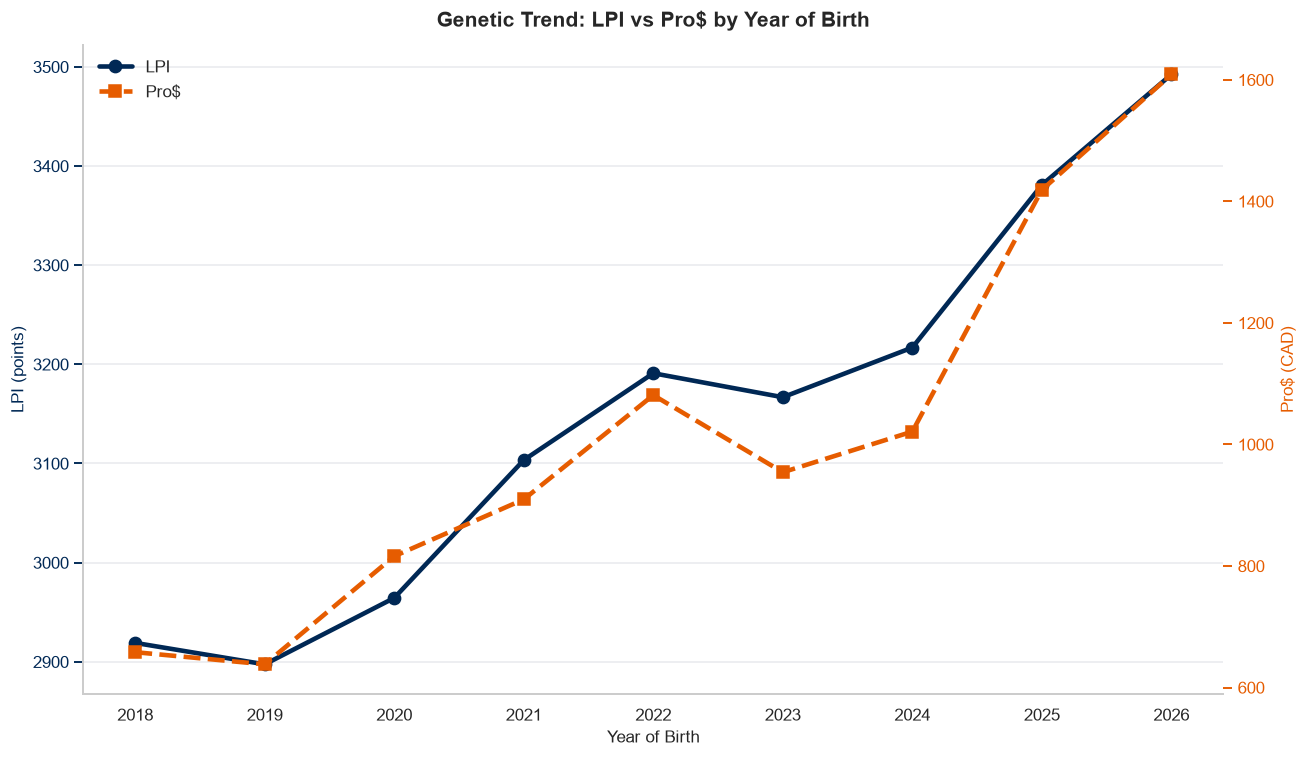

         LPI    Pro$
year                
2018  2919.0   658.0
2019  2897.0   638.0
2020  2964.0   816.0
2021  3103.0   910.0
2022  3191.0  1081.0
2023  3167.0   954.0
2024  3217.0  1021.0
2025  3381.0  1419.0
2026  3492.0  1609.0


In [50]:
# =====================================================================
# GENETIC TREND: LPI vs Pro$ by year of birth
# =====================================================================
df["year"] = pd.to_datetime(df["Birth Date"], errors="coerce").dt.year
for c in ["LPI","Pro$"]: df[c] = pd.to_numeric(df[c], errors="coerce")
sub = df[df["year"] >= 2018]
g = sub.groupby("year")[["LPI","Pro$"]].mean()

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(g.index, g["LPI"], marker="o", lw=3, ms=8, color="#002855", label="LPI")
ax1.set_ylabel("LPI (points)", color="#002855"); ax1.tick_params(axis="y", colors="#002855")
ax2 = ax1.twinx()
ax2.plot(g.index, g["Pro$"], marker="s", lw=3, ms=8, ls="--", color="#e65c00", label="Pro$")
ax2.set_ylabel("Pro$ (CAD)", color="#e65c00"); ax2.tick_params(axis="y", colors="#e65c00"); ax2.grid(False)

ax1.set_title("Genetic Trend: LPI vs Pro$ by Year of Birth")
ax1.set_xlabel("Year of Birth"); ax1.set_xticks(g.index)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left", frameon=False)
plt.tight_layout(); plt.savefig("outputs/trend_lpi_prodollar.png", dpi=150, bbox_inches="tight"); plt.show()
print(g.round(0).to_string())

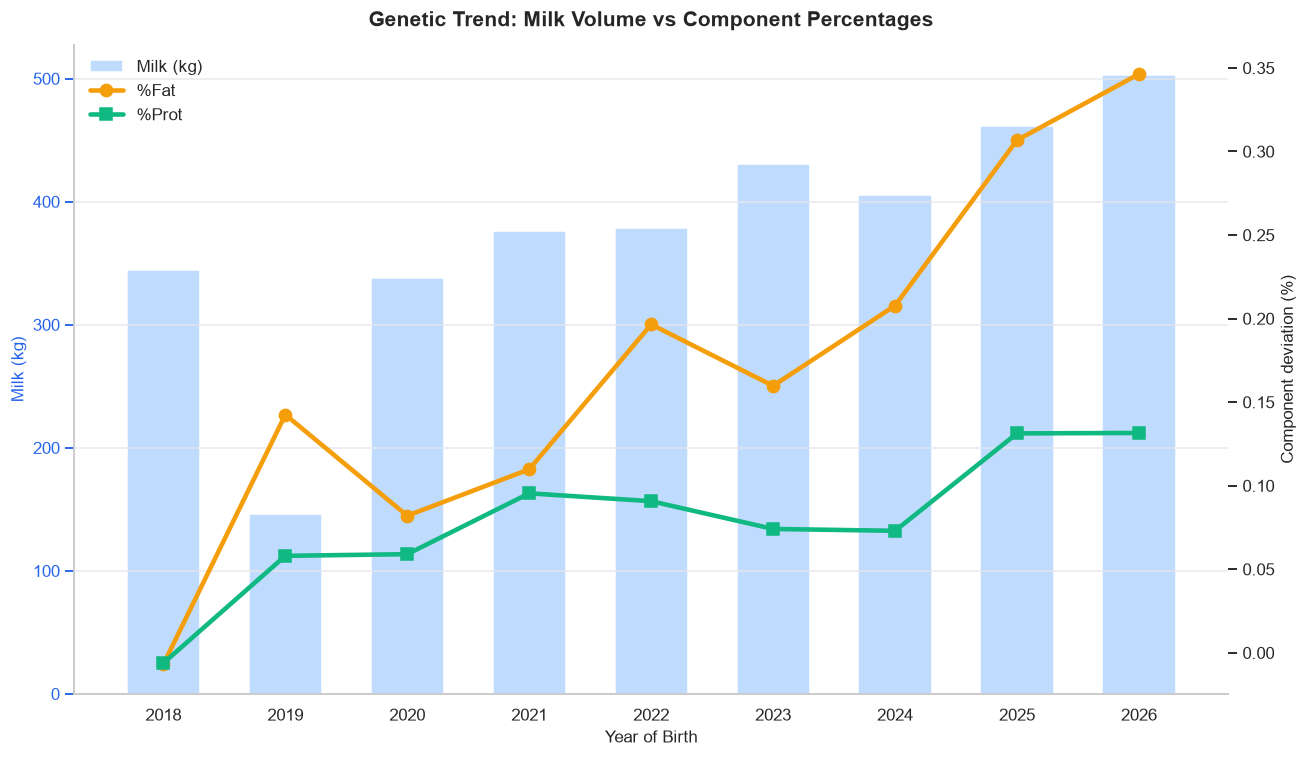

      Milk (kg)  %Fat  %Prot
year                        
2018     344.62 -0.01  -0.01
2019     146.40  0.14   0.06
2020     338.17  0.08   0.06
2021     375.79  0.11   0.10
2022     378.73  0.20   0.09
2023     430.41  0.16   0.07
2024     405.01  0.21   0.07
2025     461.11  0.31   0.13
2026     502.53  0.35   0.13


In [51]:
# =====================================================================
# GENETIC TREND: Milk (kg) vs %Fat vs %Prot by year of birth
# =====================================================================
for c in ["Milk (kg)","%Fat","%Prot"]: df[c] = pd.to_numeric(df[c], errors="coerce")
g = df[df["year"] >= 2018].groupby("year")[["Milk (kg)","%Fat","%Prot"]].mean()

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.bar(g.index, g["Milk (kg)"], color="#BFDBFE", width=0.6, label="Milk (kg)", zorder=0)
ax1.set_ylabel("Milk (kg)", color="#2563EB"); ax1.tick_params(axis="y", colors="#2563EB")
ax2 = ax1.twinx()
ax2.plot(g.index, g["%Fat"],  marker="o", lw=3, ms=8, color="#F59E0B", label="%Fat",  zorder=3)
ax2.plot(g.index, g["%Prot"], marker="s", lw=3, ms=8, color="#10B981", label="%Prot", zorder=3)
ax2.set_ylabel("Component deviation (%)"); ax2.grid(False)
ax1.set_zorder(0); ax2.set_zorder(1); ax1.patch.set_visible(False)

ax1.set_title("Genetic Trend: Milk Volume vs Component Percentages")
ax1.set_xlabel("Year of Birth"); ax1.set_xticks(g.index)
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left", frameon=False)
plt.tight_layout(); plt.savefig("outputs/trend_milk_components.png", dpi=150, bbox_inches="tight"); plt.show()
print(g.round(2).to_string())

### Genomic characterization: what the data shows

**Sire diversity.** The 668 animals descend from **212 unique sires** (identified by
registration number, not by name). Usage is concentrated: the top sire,
**DELTA-LAMBDA, has 37 offspring (5.5%)**, and the **top 10 sires account for 192
animals (29% of the herd)**. This concentration is the most likely driver of the
rising inbreeding trend observed below.

**Breeding strategy.** Of the animals with a recorded group, **190 are Sexed** and
**63 Conventional**, plus 26 Beef and 1 IVF — a clear replacement-oriented strategy.

**Milk protein genotype (A2).** Of **498 tested animals**, **270 are A2/A2 (54%)**,
197 A1/A2 (40%) and 31 A1/A1 (6%); 170 were not tested. Over half the tested herd
already qualifies for A2 milk markets.

**Polled status.** Only **36 of 185 tested animals carry the polled allele**
(34 HP carriers, 2 PP homozygous) while 149 are horned; 483 were not tested.
Polled genetics are still marginal in this herd.

**Functional index profile (breed base = 500).** The herd is strongest in
**L-TYPE (630)** and **PROD (549)**, near base for **HEALTH (514)** and
**M-ABILITY (493)**, and **below base for REPRO (486) and ENVIRO (477)**.
Selection has favoured type and production over reproduction and environmental
efficiency.

**Genetic trend (LPI vs Pro$).** Both indexes improved across birth-year cohorts:
**LPI rose from 2,919 (2018) to 3,492 (2026)** and **Pro$ from 658 to 1,609** —
Pro$ grew proportionally much faster (+145%) than LPI (+20%).

**Production trend.** Milk volume increased from **345 kg (2018) to 503 kg (2026)**
while **%Fat rose from −0.01 to +0.35** and **%Prot from −0.01 to +0.13**,
showing simultaneous gain in volume *and* components — not the classic dilution
trade-off.

**Caveat.** All values are genomic/parental evaluations, not measured performance,
and cohorts before 2021 contain few animals (2013 and 2015 have n = 1).

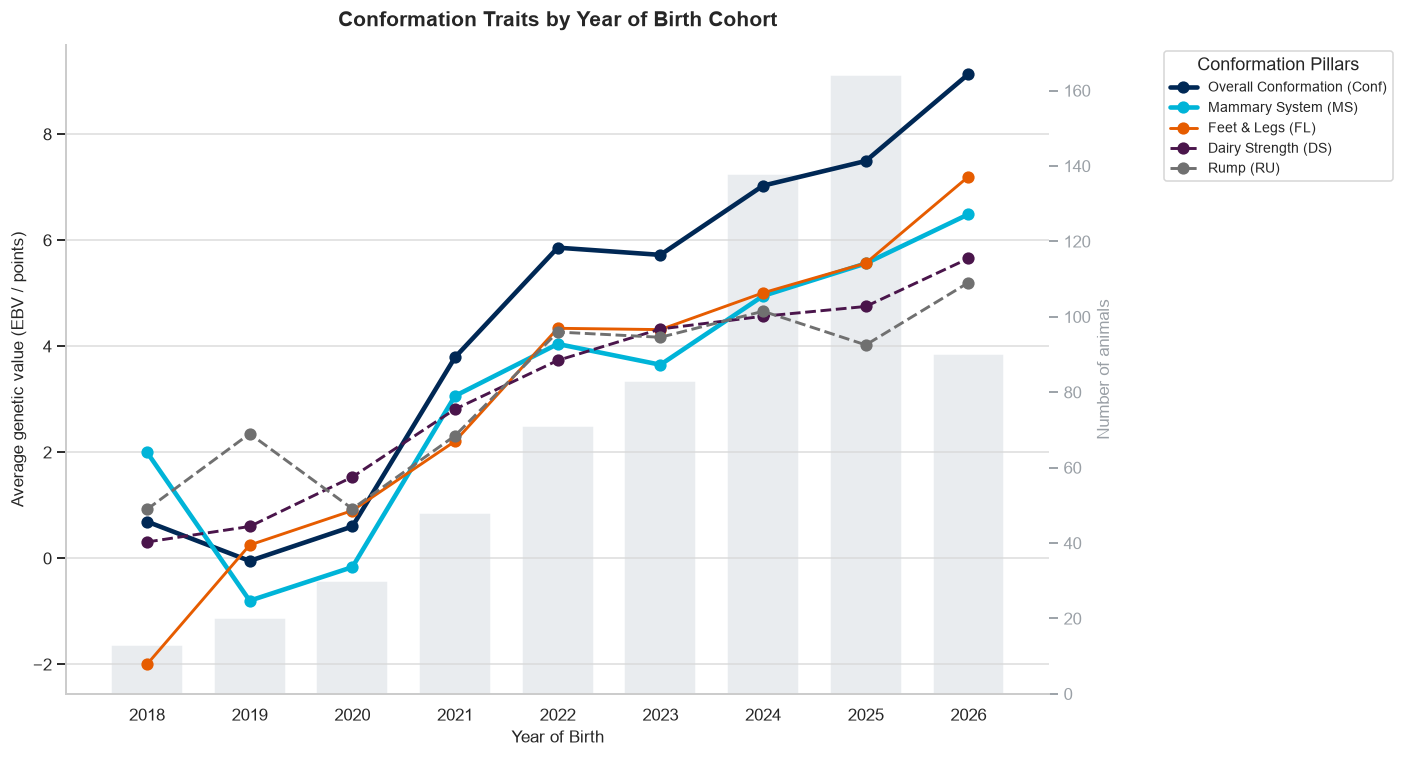

      Conf    MS    FL    DS    RU
year                              
2018  0.69  2.00 -2.00  0.31  0.92
2019 -0.05 -0.80  0.25  0.60  2.35
2020  0.60 -0.17  0.90  1.53  0.93
2021  3.79  3.06  2.21  2.81  2.31
2022  5.86  4.04  4.34  3.73  4.27
2023  5.72  3.65  4.31  4.33  4.17
2024  7.03  4.95  5.01  4.57  4.66
2025  7.49  5.56  5.57  4.75  4.02
2026  9.13  6.49  7.20  5.66  5.20

Change 2018 -> 2026 (points):
 RU      4.28
MS      4.49
DS      5.35
Conf    8.44
FL      9.20

Slowest pillar: RU


In [68]:
# =====================================================================
# CONFORMATION TREND by year of birth (Conf, MS, FL, DS, RU)
# =====================================================================
conformation_map = {"Conf":"Overall Conformation", "MS":"Mammary System",
                    "FL":"Feet & Legs", "DS":"Dairy Strength", "RU":"Rump"}
cols = list(conformation_map.keys())
for c in cols: df[c] = pd.to_numeric(df[c], errors="coerce")
df["year"] = pd.to_datetime(df["Birth Date"], errors="coerce").dt.year

sub    = df[df["year"] >= 2018]                 # cohorts with enough animals
trend  = sub.groupby("year")[cols].mean()
counts = sub.groupby("year").size()

trait_colors = {"Conf":"#002855","MS":"#00b4d8","FL":"#e65c00",
                "DS":"#4a154b","RU":"#707070"}

fig, ax1 = plt.subplots(figsize=(13, 7))
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values, color="#E9ECEF", width=0.7, zorder=0)
ax2.set_ylabel("Number of animals", color="#9AA0A6")
ax2.tick_params(axis="y", colors="#9AA0A6"); ax2.grid(False)

for c in cols:
    ax1.plot(trend.index, trend[c], marker="o", ms=7,
             lw=3.0 if c in ("Conf","MS") else 1.9,
             ls="-" if c in ("Conf","MS","FL") else "--",
             color=trait_colors[c], label=f"{conformation_map[c]} ({c})", zorder=3)
ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)

ax1.set_title("Conformation Traits by Year of Birth Cohort")
ax1.set_xlabel("Year of Birth"); ax1.set_ylabel("Average genetic value (EBV / points)")
ax1.set_xticks(trend.index); ax1.grid(True, axis="y", color="#D9D9D9", alpha=0.9)
ax1.legend(title="Conformation Pillars", bbox_to_anchor=(1.11, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig("outputs/trend_conformation.png", dpi=150, bbox_inches="tight"); plt.show()

print(trend.round(2).to_string())
gain = (trend.iloc[-1] - trend.iloc[0]).sort_values()
print("\nChange 2018 -> 2026 (points):\n", gain.round(2).to_string())
print("\nSlowest pillar:", gain.index[0])

STRUCTURAL INTEGRITY
Rows (animals) : 668
Columns        : 168
Unique Registration Number: 668  |  duplicates: 0
Fully empty columns (2): ['Chain Number', 'Original Dam Reg Number']
Fully duplicated rows: 0

COMPLETENESS BY VARIABLE
                     n_present  n_missing  pct_missing
Color Test                 185        483         72.3
Polled Test                185        483         72.3
Current group              280        388         58.1
Genomic Inb. %             489        179         26.8
HO%                        489        179         26.8
A2 Test                    498        170         25.4
KappaBB                    498        170         25.4
Lactoglobulin              498        170         25.4
BetaCasein                 498        170         25.4
MGS Name                   665          3          0.4
Dam                        665          3          0.4
Sire Name                  666          2          0.3
Sire Reg Number            666          2          0

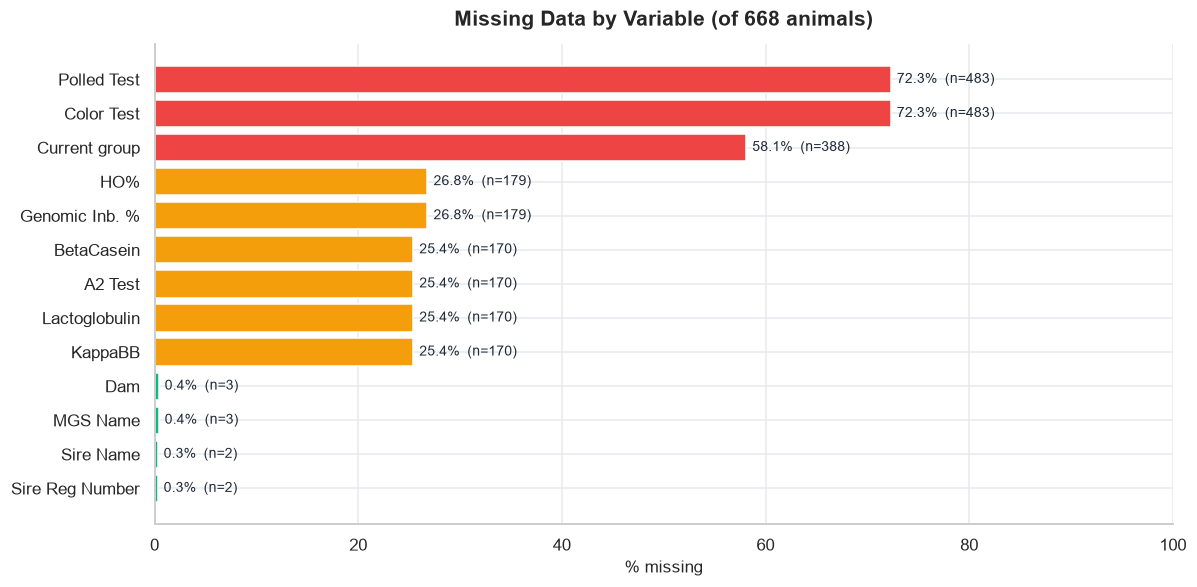


RANGE / OUTLIER CHECK (IQR rule)
                   min     max  outliers
variable                                
Milk (kg)      -1742.0  1921.0         4
Fat (kg)         -62.0   160.0         9
Prot (kg)        -38.0    88.0         4
SCS               92.0   111.0         0
LPI             2300.0  3902.0         4
Pro$           -1528.0  3027.0         2
Genomic Inb. %     2.6    25.0        14

MARKER CODING CHECK (values are carrier PROBABILITY %, not flags)
  BLAD   min=  0 max=  1 carriers(>=50%)=  0
  BY     min=  0 max= 99 carriers(>=50%)=  3
  CIT    min=  0 max=  1 carriers(>=50%)=  0
  CVM    min=  0 max= 99 carriers(>=50%)=  1
  DUMPS  min=  0 max=  1 carriers(>=50%)=  0
  MF     min=  0 max=  1 carriers(>=50%)=  0
  HH1    min=  0 max= 99 carriers(>=50%)=  4
  HH2    min=  0 max= 99 carriers(>=50%)=  9
  HH3    min=  0 max= 99 carriers(>=50%)=  5
  HH4    min=  0 max=  1 carriers(>=50%)=  0
  HH5    min=  0 max= 99 carriers(>=50%)= 29
  HH6    min=  0 max= 99 carriers(>

In [69]:
# =====================================================================
# EDA - DATA QUALITY AND COMPLETENESS AUDIT
# Required step "before performing statistical analyses"
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.bbox": "tight", "figure.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.alpha": 0.9,
    "axes.axisbelow": True, "font.size": 10.5,
})

# ---- 1. LOAD ----
df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
N = len(df)

# ---- 2. STRUCTURAL INTEGRITY ----
print("=" * 70); print("STRUCTURAL INTEGRITY"); print("=" * 70)
print(f"Rows (animals) : {N}")
print(f"Columns        : {df.shape[1]}")
id_col = "Registration Number"
if id_col in df.columns:
    print(f"Unique {id_col}: {df[id_col].nunique()}  |  duplicates: {int(df[id_col].duplicated().sum())}")
empty_cols = [c for c in df.columns if df[c].isna().all()]
print(f"Fully empty columns ({len(empty_cols)}): {empty_cols}")
print(f"Fully duplicated rows: {int(df.duplicated().sum())}")

# ---- 3. COMPLETENESS BY VARIABLE ----
key_vars = ["Registration Number", "Birth Date", "Type", "Genotyped", "Proof Source",
            "Lact. Number", "LPI", "Pro$", "Client Index",
            "Milk (kg)", "Fat (kg)", "%Fat", "Prot (kg)", "%Prot", "SCS", "HL",
            "Conf", "MS", "FL", "DS", "RU",
            "PROD", "HEALTH", "L-TYPE", "REPRO", "M-ABILITY", "ENVIRO",
            "Genomic Inb. %", "HO%", "A2 Test", "KappaBB", "Lactoglobulin",
            "BetaCasein", "Polled Test", "Color Test", "Current group",
            "Sire Reg Number", "Sire Name", "Dam", "MGS Name"]
key_vars = [c for c in key_vars if c in df.columns]

quality = pd.DataFrame({
    "n_present": [int(df[c].notna().sum()) for c in key_vars],
    "n_missing": [int(df[c].isna().sum()) for c in key_vars],
}, index=key_vars)
quality["pct_missing"] = (quality["n_missing"] / N * 100).round(1)
quality = quality.sort_values("pct_missing", ascending=False)

print("\n" + "=" * 70); print("COMPLETENESS BY VARIABLE"); print("=" * 70)
print(quality.to_string())
quality.to_csv("outputs/data_quality_report.csv")

# ---- 4. FIGURE: variables with missing data ----
miss = quality[quality["pct_missing"] > 0].sort_values("pct_missing")
if len(miss):
    fig, ax = plt.subplots(figsize=(11, max(4, 0.42 * len(miss))))
    colors = ["#EF4444" if v >= 50 else "#F59E0B" if v >= 20 else "#10B981"
              for v in miss["pct_missing"]]
    b = ax.barh(miss.index, miss["pct_missing"], color=colors, edgecolor="white")
    for bar, n in zip(b, miss["n_missing"]):
        w = bar.get_width()
        ax.text(w + 0.6, bar.get_y() + bar.get_height()/2,
                f"{w:.1f}%  (n={int(n)})", va="center", fontsize=9, color="#1F2937")
    ax.set_title(f"Missing Data by Variable (of {N} animals)")
    ax.set_xlabel("% missing"); ax.set_xlim(0, 100); ax.grid(True, axis="x")
    plt.tight_layout()
    plt.savefig("outputs/data_quality_missing.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---- 5. RANGE AND OUTLIER CHECK ----
num_check = ["Milk (kg)", "Fat (kg)", "Prot (kg)", "SCS", "LPI", "Pro$", "Genomic Inb. %"]
num_check = [c for c in num_check if c in df.columns]
print("\n" + "=" * 70); print("RANGE / OUTLIER CHECK (IQR rule)"); print("=" * 70)
rows = []
for c in num_check:
    s = pd.to_numeric(df[c], errors="coerce")
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    rows.append({"variable": c, "min": s.min(), "max": s.max(),
                 "outliers": int(((s < lo) | (s > hi)).sum())})
outliers = pd.DataFrame(rows).set_index("variable").round(1)
print(outliers.to_string())
outliers.to_csv("outputs/outlier_report.csv")

# ---- 6. SPECIAL CODE CHECK: carrier probabilities use 99 = carrier ----
markers = [c for c in ["BLAD","BY","CIT","CVM","DUMPS","MF",
                       "HH1","HH2","HH3","HH4","HH5","HH6","HCD","HMW"] if c in df.columns]
if markers:
    print("\n" + "=" * 70)
    print("MARKER CODING CHECK (values are carrier PROBABILITY %, not flags)")
    print("=" * 70)
    for c in markers:
        s = pd.to_numeric(df[c], errors="coerce")
        print(f"  {c:6s} min={s.min():3.0f} max={s.max():3.0f} "
              f"carriers(>=50%)={int((s >= 50).sum()):3d}")

In [ ]:
### Data Quality and Completeness Audit

Before any statistical analysis, the dataset was audited for structural integrity,
completeness and value ranges.

**Structural integrity.** The file contains **668 animals × 138 variables**. Every
animal has a unique **Registration Number** (668 unique, **0 duplicates**) and there
are **no fully duplicated rows**. Two columns are **completely empty**
(`Chain Number`, `Original Dam Reg Number`) and were excluded.

**Completeness.** Core identification and genetic-evaluation variables are
**100% complete**: Birth Date, Type, Genotyped, Proof Source, Lactation Number, LPI,
Pro$, Client Index, all production traits (Milk, Fat, %Fat, Protein, %Prot), SCS, HL,
all conformation traits (Conf, MS, FL, DS, RU) and all six functional subindexes
(PROD, HEALTH, L-TYPE, REPRO, M-ABILITY, ENVIRO). Pedigree is nearly complete
(**Sire Reg Number missing for only 2 animals, 0.3%**).

Laboratory-dependent variables are the incomplete ones, because they are **optional
paid tests**, not data-entry errors:

| Variable | Missing | % |
|---|---|---|
| Polled Test / Color Test | 483 | 72.3% |
| Current group | 388 | 58.1% |
| Genomic Inb. % / HO% | 179 | 26.8% |
| A2 Test / KappaBB / Lactoglobulin / BetaCasein | 170 | 25.4% |

**Implication:** analyses on inbreeding (n = 489), milk-protein genotypes (n = 498)
and polled status (n = 185) are restricted to tested subsets and are **not
herd-wide**. Missing values were **never imputed** — a zero in a genetic evaluation
would be a false value, not an absence.

**Ranges and outliers.** Genomic evaluations are deviations, so **negative values are
biologically valid** (e.g. Milk from −1,742 to +1,921 kg; Pro$ from −1,528 to +3,027).
IQR-flagged points are few (Milk 4, Fat 9, Protein 4, LPI 4, Pro$ 2) and represent
genuine genetic extremes, so they were **retained**. Genomic inbreeding ranges from
**2.6% to 25.0%** (14 IQR outliers) — the high tail is a real management finding, not
an error.

**Marker coding.** Per the Semex glossary, BLAD, CVM, DUMPS, Brachyspina and the
HH1–HH6 / HCD / HMW haplotypes store the **probability that the animal is a carrier**
(0 = free, 99 = carrier), **not** a binary flag. Treating these columns as 0/1 flags
would invert the interpretation; carriers were therefore defined as probability ≥ 50%.

**Conclusion:** the dataset is structurally sound and complete for all genetic
evaluations. The only limitation is the coverage of optional lab tests, which
restricts sample size for specific sub-analyses but does not compromise the core
genomic analysis.